# PREVISIONE QUALITÀ DELL'ARIA
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione

### 1.1 Obiettivo

L'obiettivo di questo progetto è di prevedere la concentrazione oraria di **PM2.5** (µg/m³) nell'area metropolitana di Pechino a partire da variabili meteorologiche, temporali e altri inquinanti atmosferici.

Il PM2.5 è particolato fine con diametro inferiore a 2.5 µm, abbastanza piccolo da penetrare nei polmoni e nel sangue. L'OMS raccomanda un limite di 15 µg/m³ per la media giornaliera. Pechino nel periodo 2013–2017 superava regolarmente questa soglia, con picchi oltre i 500 µg/m³.

Un modello accurato di previsione del PM2.5 ha applicazioni concrete: sistemi di allerta precoce per la popolazione, supporto alla pianificazione di politiche ambientali, e valutazione della possibilità di stimare l'inquinamento usando solo dati meteo.

Questo tema è rilevante anche nel contesto italiano: la Pianura Padana è tra le zone peggiori d'Europa per PM2.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42

### 1.2 Importazione del dataset

I dataset utilizzati sono stati ottenuti da [**Beijing Multi-Site Air-Quality Data**](https://doi.org/10.24432/C5RK5G). Contengono misurazioni orarie da 12 stazioni di monitoraggio di Pechino nel periodo marzo 2013 – febbraio 2017.

Le feature si suddividono in quattro categorie:

**Temporali:** `year`, `month`, `day`, `hour`.

**Inquinanti** (µg/m³):
- `PM2.5`: particolato fine, target della previsione
- `PM10`: particolato grossolano, spesso co-emesso con il PM2.5
- `SO2`: biossido di zolfo, da combustione di carbone
- `NO2`: biossido di azoto, da traffico e centrali termiche
- `CO`: monossido di carbonio, indicatore di combustione incompleta
- `O3`: ozono, inquinante secondario con comportamento opposto agli altri (alto quando PM2.5 è basso)

**Meteorologiche:**
- `TEMP` (°C): temperatura dell'aria, influenza la stabilità atmosferica e la dispersione degli inquinanti
- `PRES` (hPa): pressione atmosferica, valori alti indicano aria stagnante che favorisce l'accumulo del particolato
- `DEWP` (°C): temperatura del punto di rugiada, misura l'umidità dell'aria; valori alti indicano aria umida che può favorire la formazione di particolato secondario
- `RAIN` (mm): precipitazioni, la pioggia lava il particolato dall'atmosfera riducendo il PM2.5
- `WSPM` (m/s): velocità del vento, venti forti disperdono gli inquinanti riducendo la concentrazione locale
- `wd`: direzione del vento (categorica), determina la provenienza delle masse d'aria e quindi il trasporto di inquinanti da aree industriali o rurali

**Metadati:** `station`: nome della stazione di monitoraggio.

In [2]:
directory = "datasets"
dfs = []
for nome_file in os.listdir(directory):
    if nome_file.endswith(".csv"):
        dfs.append(pd.read_csv(os.path.join(directory, nome_file), index_col=False))

df = pd.concat(dfs, ignore_index=True)

if 'No' in df.columns:
    df = df.drop(columns=['No'])

df.info(verbose=False, memory_usage='deep')
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Columns: 17 entries, year to station
dtypes: float64(11), int64(4), object(2)
memory usage: 98.1 MB


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping


La colonna `No` (identificatore) viene rimossa in fase di caricamento poiché non informativa.

## 2. Analisi esplorativa dei dati

### 2.1 Statistiche generali

In [3]:
df.describe().round(2)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


Il PM2.5 medio è circa 80 µg/m³ con una deviazione standard di ~81, segnale di una distribuzione molto dispersa. Il massimo raggiunge 999 µg/m³, un valore estremo che potrebbe indicare un evento eccezionale o un'anomalia del sensore. Gli altri inquinanti (PM10, SO2, NO2, CO) mostrano un pattern simile con concentrazione a sinistra. Le variabili meteorologiche hanno range coerenti con il clima continentale di Pechino.

In [4]:
nan_counts = df.isnull().sum()
nan_percentages = (nan_counts / len(df) * 100).round(2)

nan_summary = pd.DataFrame({
    '# NaN': nan_counts,
    '% NaN': nan_percentages
}).sort_values('% NaN', ascending=False)

nan_summary = nan_summary[nan_summary['# NaN'] > 0]
nan_summary

,# NaN,% NaN
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
TEMP,398,0.09


Si osserva che le variabili temporali (year, month, day, hour) e station non hanno valori mancanti.
Gli inquinanti, invece, presentano la percentuale più alta di NaN, dovuta probabilmente a malfunzionamenti dei sensori.
Le variabili meteorologiche sono quasi complete: TEMP, PRES, DEWP, RAIN e WSPM.

La percentuale di NaN rimane comunque contenuta per tutte le colonne, rendendo il dataset complessivamente affidabile. I valori mancanti verranno gestiti nella fase di preparazione dei dati (sezione 3).

### 2.2 Distribuzione del target (PM2.5)

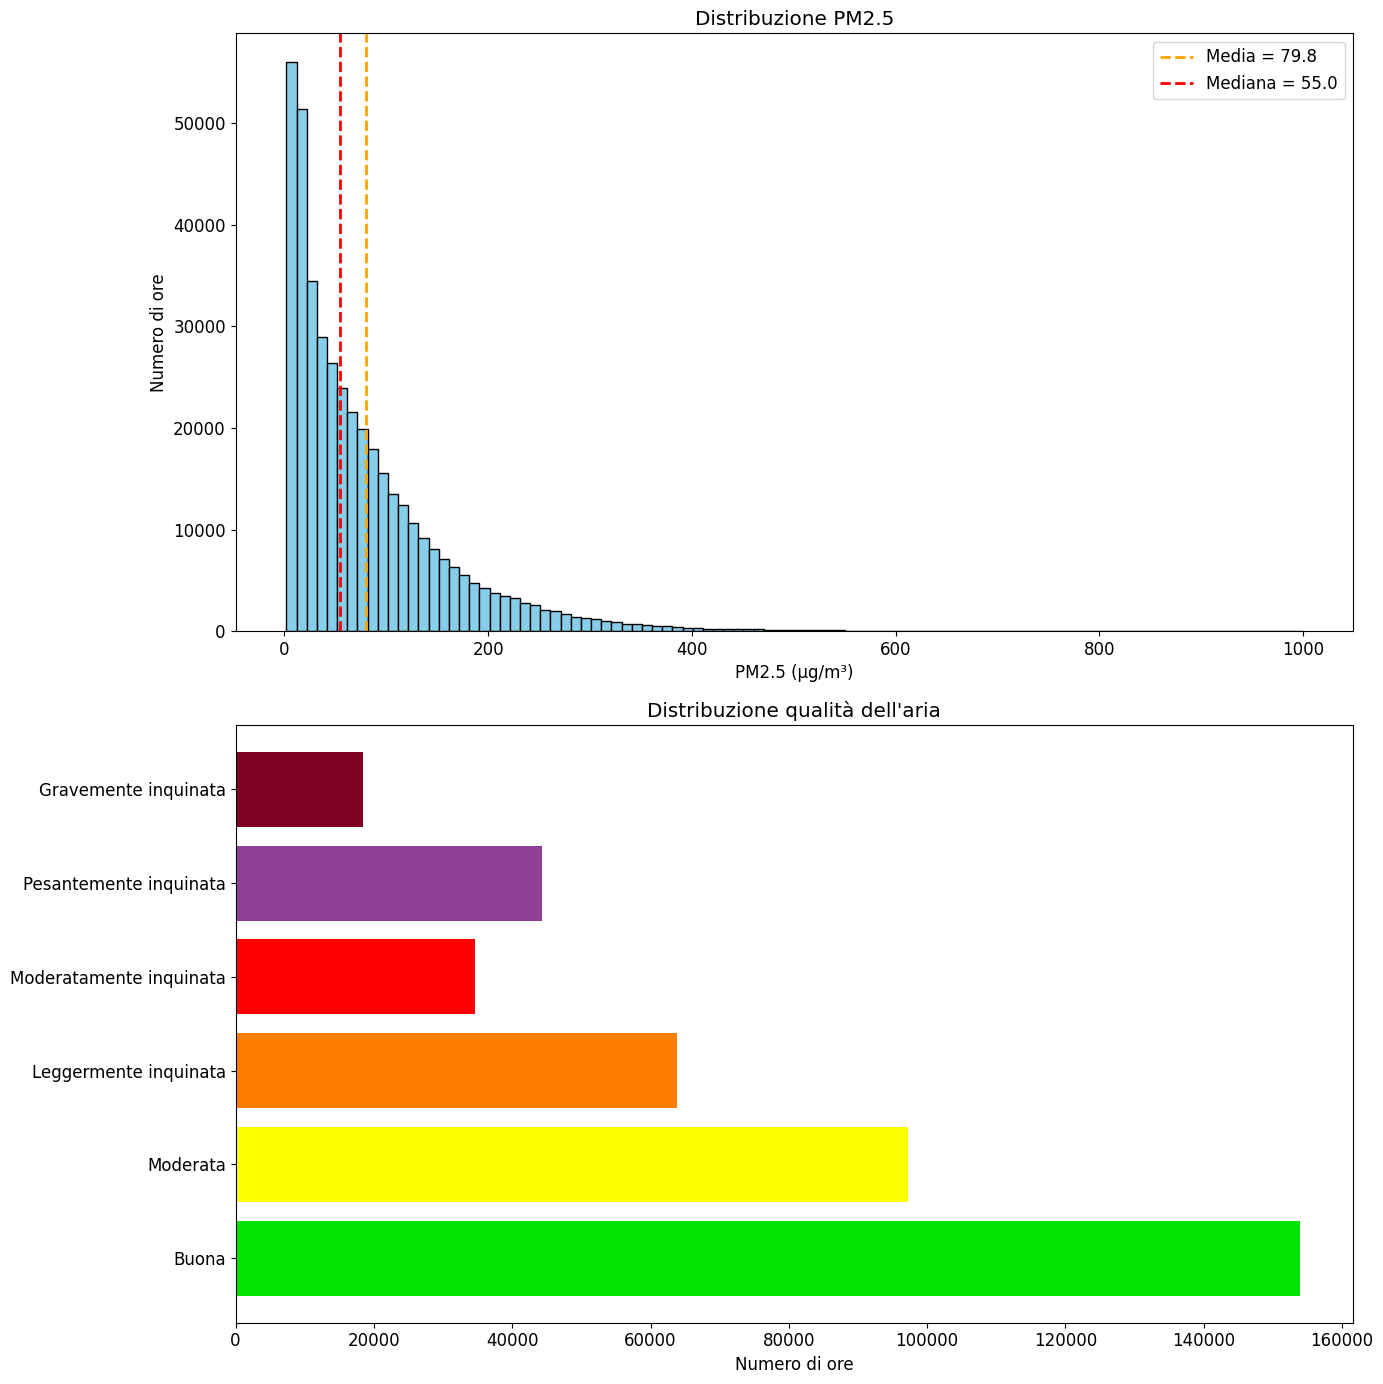

Media: 79.8 µg/m³
Mediana: 55.0 µg/m³
Std: 80.8
Min: 2
Max: 999
Ore con aria buona (≤35): 37.3%
Ore con livelli dannosi (>115): 23.6%


In [5]:
pm25 = df['PM2.5'].dropna()

mean_val = pm25.mean()
median_val = pm25.median()

# Fasce di qualità dell'aria
aqi_labels = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]

aqi_cat = pd.cut(pm25, bins=aqi_bins, labels=aqi_labels, include_lowest=True)
aqi_counts = aqi_cat.value_counts().reindex(aqi_labels)

# Figura
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Istogramma
axes[0].hist(pm25, bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Media = {mean_val:.1f}')
axes[0].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Mediana = {median_val:.1f}')
axes[0].set_title('Distribuzione PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Numero di ore')
axes[0].legend()

# Categorie AQI
axes[1].barh(aqi_counts.index, aqi_counts.values, color=aqi_colors)
axes[1].set_title("Distribuzione qualità dell'aria")
axes[1].set_xlabel('Numero di ore')

# Statistiche
pct_buona = (pm25 <= 35).sum() / len(pm25) * 100
pct_insalubre = (pm25 > 115).sum() / len(pm25) * 100

plt.tight_layout()
plt.show()

print(f"Media: {mean_val:.1f} µg/m³\nMediana: {median_val:.1f} µg/m³")
print(f"Std: {pm25.std():.1f}")
print(f"Min: {pm25.min():.0f}\nMax: {pm25.max():.0f}")
print(f"Ore con aria buona (≤35): {pct_buona:.1f}%")
print(f"Ore con livelli dannosi (>115): {pct_insalubre:.1f}%")

La distribuzione del PM2.5 è asimmetrica: la maggior parte delle ore ha valori tra 0 e 100 µg/m³, ma ci sono picchi che superano i 500 µg/m³. Solo il 37% delle ore ha aria "buona" (≤35 µg/m³), mentre il 23.6% rientra nelle categorie con livelli dannosi.

### 2.3 Analisi temporale

Creazione di un'unica colonna `datetime` a partire dalle variabili temporali separate, da cui si estrae il giorno della settimana `weekday` (0 = lunedì, 6 = domenica).

In [6]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['weekday'] = df['datetime'].dt.dayofweek

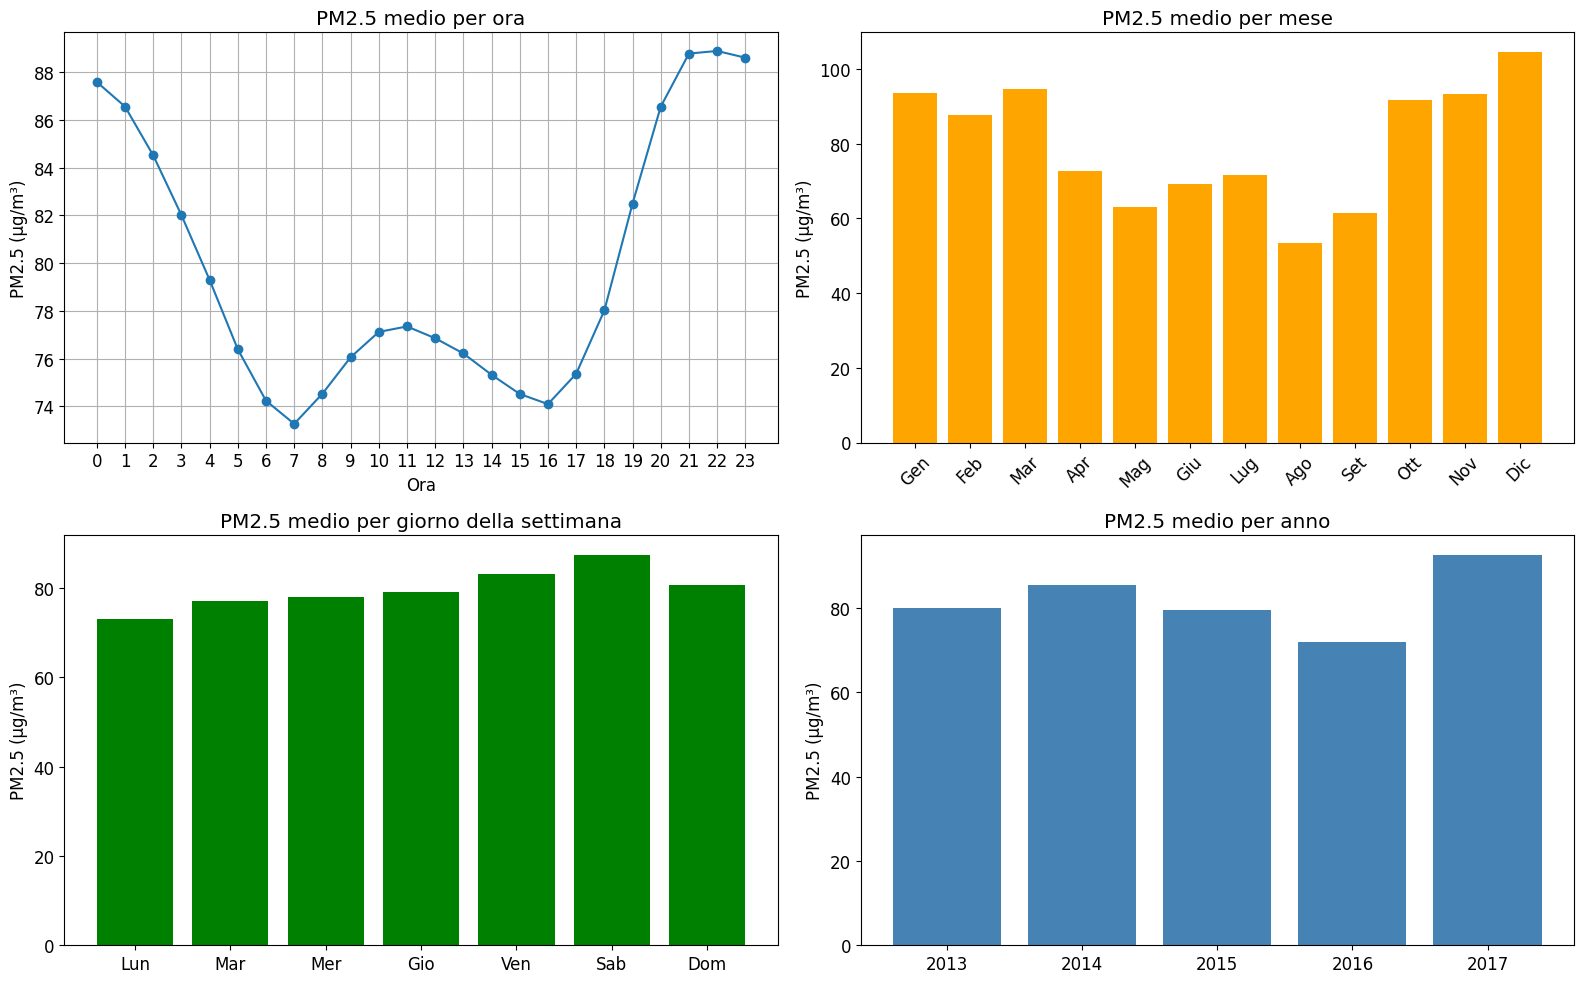

In [7]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()
monthly_pm25 = df.groupby('month')['PM2.5'].mean()

mesi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

weekday_map = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Gio', 4:'Ven', 5:'Sab', 6:'Dom'}
weekday_pm25 = df.groupby('weekday')['PM2.5'].mean().rename(index=weekday_map)

yearly_pm25 = df.groupby('year')['PM2.5'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orario
axes[0,0].plot(hourly_pm25.index, hourly_pm25.values, marker='o')
axes[0,0].set_title('PM2.5 medio per ora')
axes[0,0].set_xlabel('Ora')
axes[0,0].set_ylabel('PM2.5 (µg/m³)')
axes[0,0].set_xticks(range(24))
axes[0,0].grid(True)

# Mensile
axes[0,1].bar(mesi, monthly_pm25.values, color='orange')
axes[0,1].set_title('PM2.5 medio per mese')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')
axes[0,1].tick_params(axis='x', rotation=45)

# Settimanale
axes[1,0].bar(weekday_pm25.index, weekday_pm25.values, color='green')
axes[1,0].set_title('PM2.5 medio per giorno della settimana')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Annuale
axes[1,1].bar(yearly_pm25.index.astype(str), yearly_pm25.values, color='steelblue')
axes[1,1].set_title('PM2.5 medio per anno')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

**Orario**: i livelli massimi si registrano durante la notte (18:00–04:00), con un minimo la mattina (6:00–08:00) e nel primo pomeriggio (14:00–17:00).

**Stagionale**: i mesi invernali mostrano valori molto più alti dell'estate.

**Settimanale**: le differenze tra giorni feriali e weekend sono minime. Questo indica che il traffico veicolare non è la causa principale del PM2.5.

**Annuale**: si osserva un lieve miglioramento nel tempo, coerente con le politiche anti-inquinamento adottate.

### 2.4 PM2.5 medio per ora e mese

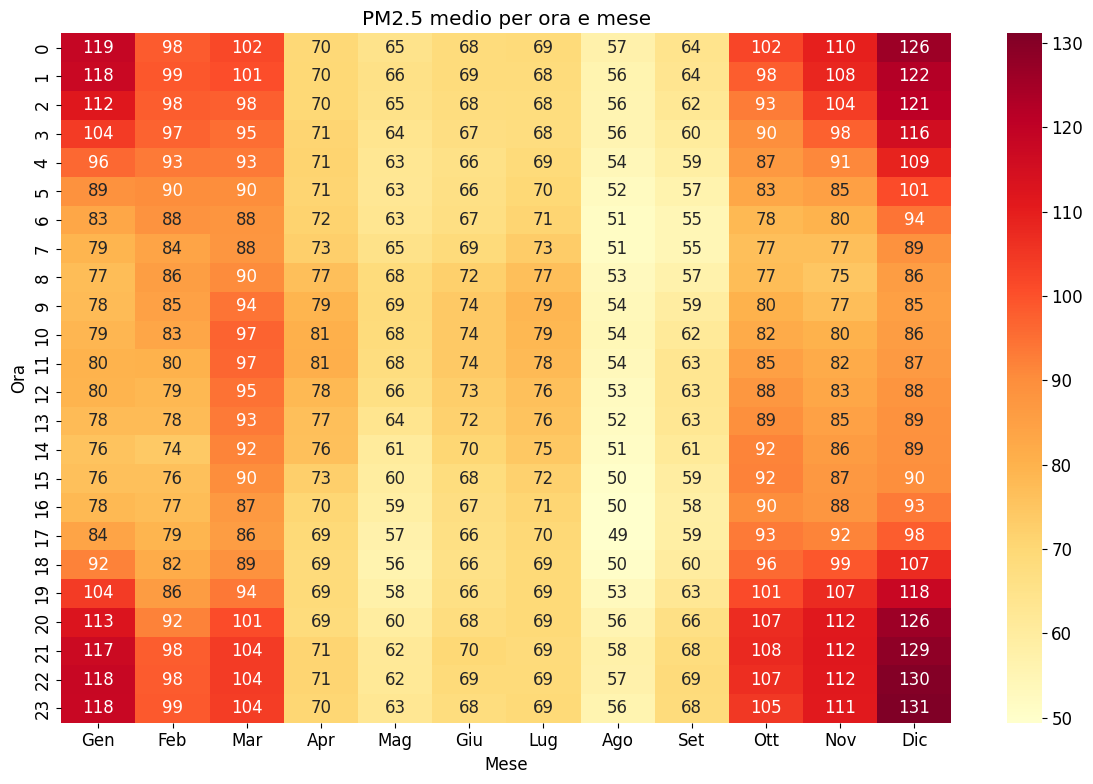

In [8]:
pivot = df.pivot_table(
    values='PM2.5',
    index='hour',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', xticklabels=mesi, yticklabels=range(24))
plt.title('PM2.5 medio per ora e mese')
plt.xlabel('Mese')
plt.ylabel('Ora')
plt.tight_layout()
plt.show()

I mesi invernali (novembre–febbraio) mostrano i valori più elevati in tutte le fasce orarie, a causa del riscaldamento domestico e delle inversioni termiche più frequenti, mentre i mesi estivi (giugno–agosto) presentano i valori più bassi.

Sul piano giornaliero si osserva un picco serale/notturno (tra le 18:00 e le 04:00) e un minimo nel primo pomeriggio (13:00–16:00). La combinazione peggiore è quindi nelle notti invernali, dove i due fattori si sommano.

### 2.5 Distribuzione variabili meteorologiche

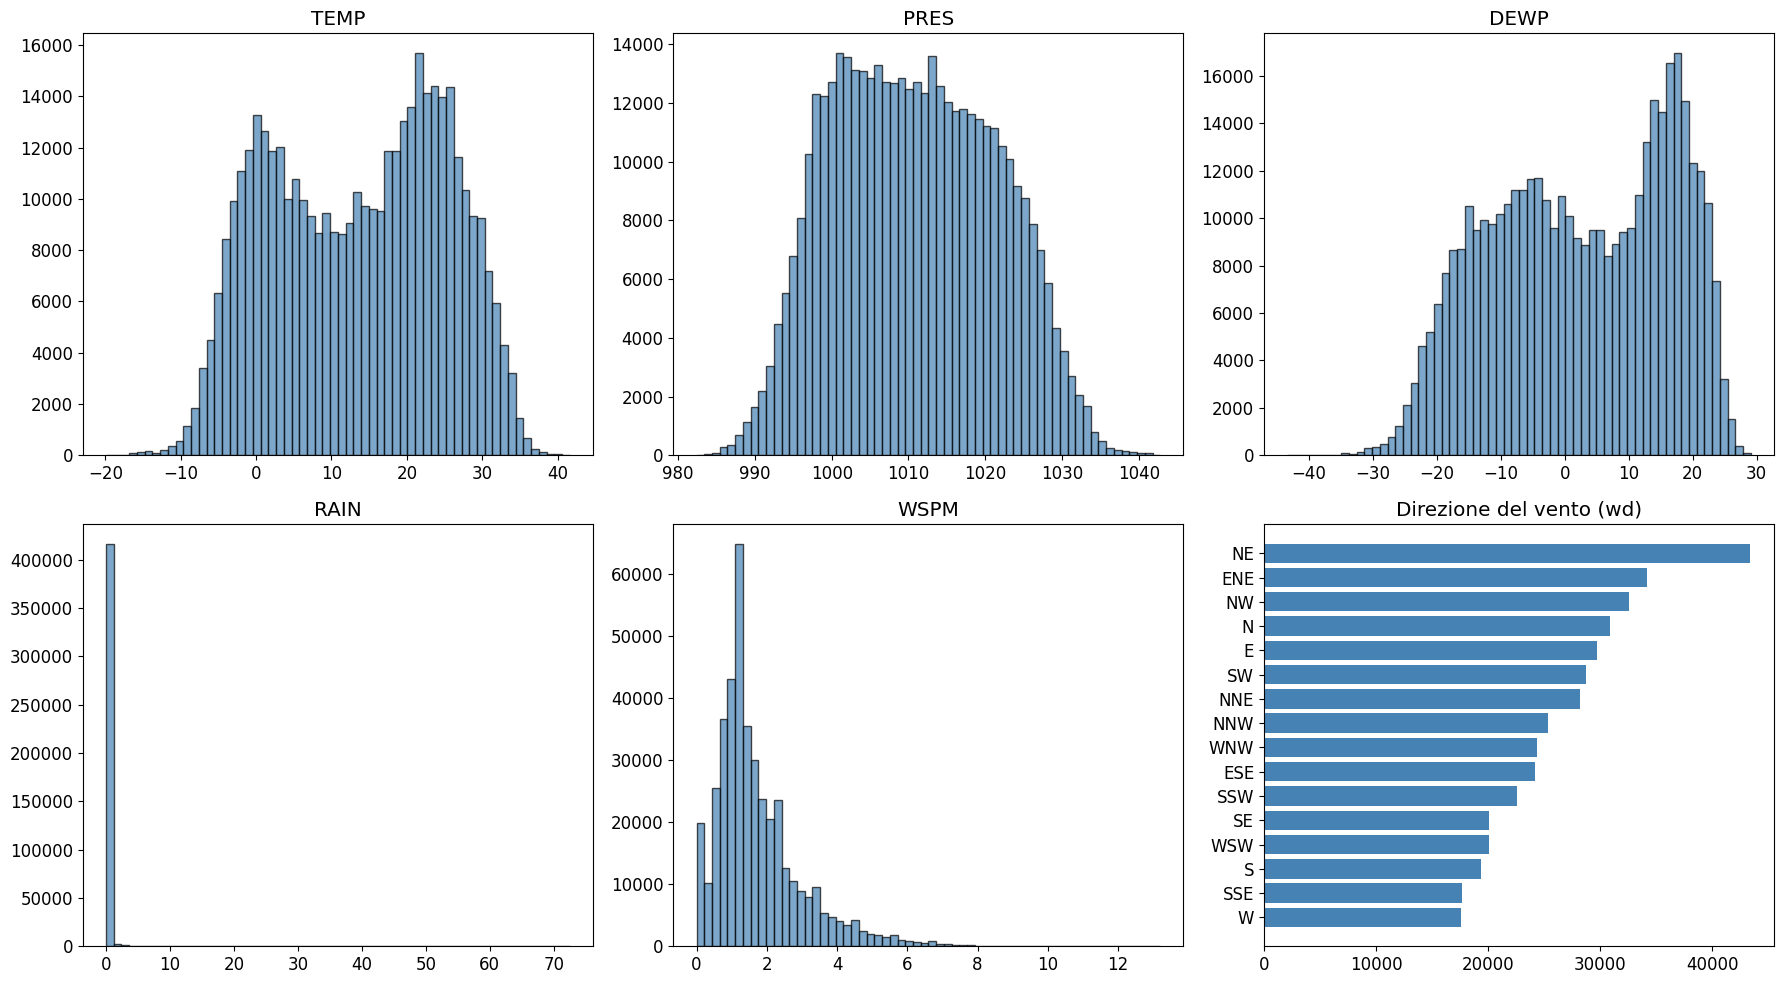

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

meteo_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for ax, var in zip(axes.flat[:5], meteo_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(var)

wd_counts = df['wd'].value_counts().sort_values(ascending=True)
axes[1,2].barh(wd_counts.index, wd_counts.values, color='steelblue')
axes[1,2].set_title('Direzione del vento (wd)')

plt.tight_layout()
plt.show()

`TEMP` ha un range di circa 60°C (da -20 a +40). `PRES` mostra una distribuzione bimodale legata alla variazione stagionale. `RAIN` è quasi esclusivamente a 0: la stragrande maggioranza delle ore ha precipitazione zero. `WSPM` è concentrato a sinistra, con prevalenza di vento debole. La direzione del vento dominante è NE.

### 2.6 Distribuzione degli inquinanti

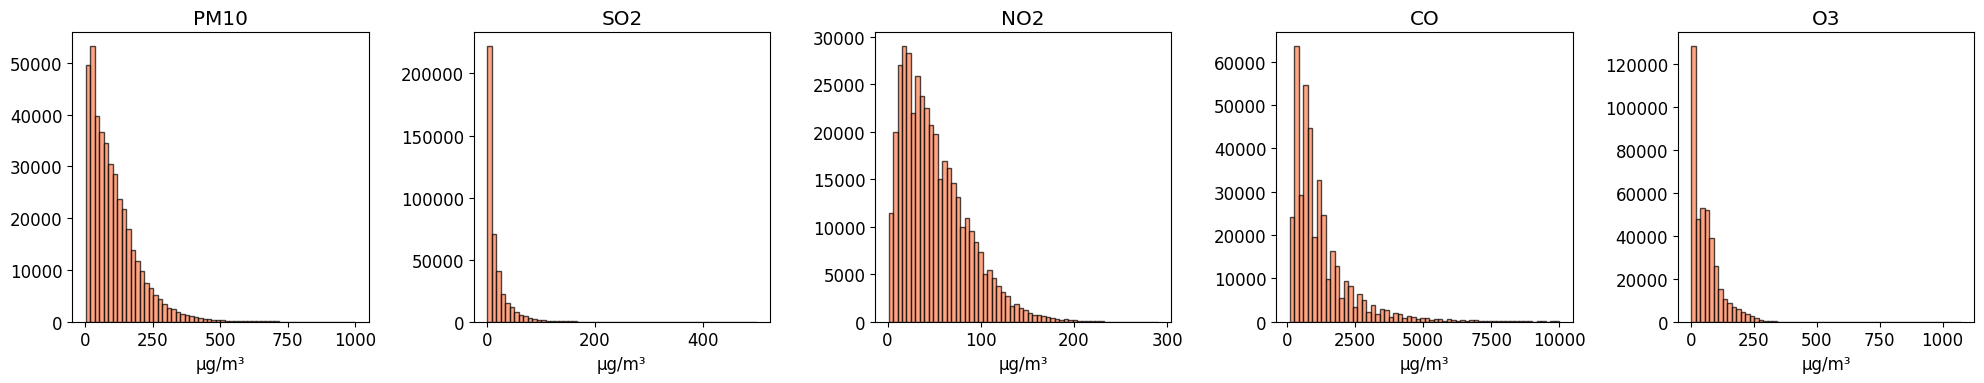

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

poll_vars = ['PM10', 'SO2', 'NO2', 'CO', 'O3']

for ax, var in zip(axes, poll_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(var)
    ax.set_xlabel('µg/m³')

plt.tight_layout()
plt.show()

Tutti gli inquinanti mostrano una distribuzione concentrata a sinistra, simile a quella del PM2.5, con la maggior parte delle rilevazioni concentrate su valori bassi e una lunga coda verso valori estremi.

### 2.7 Analisi per stazione

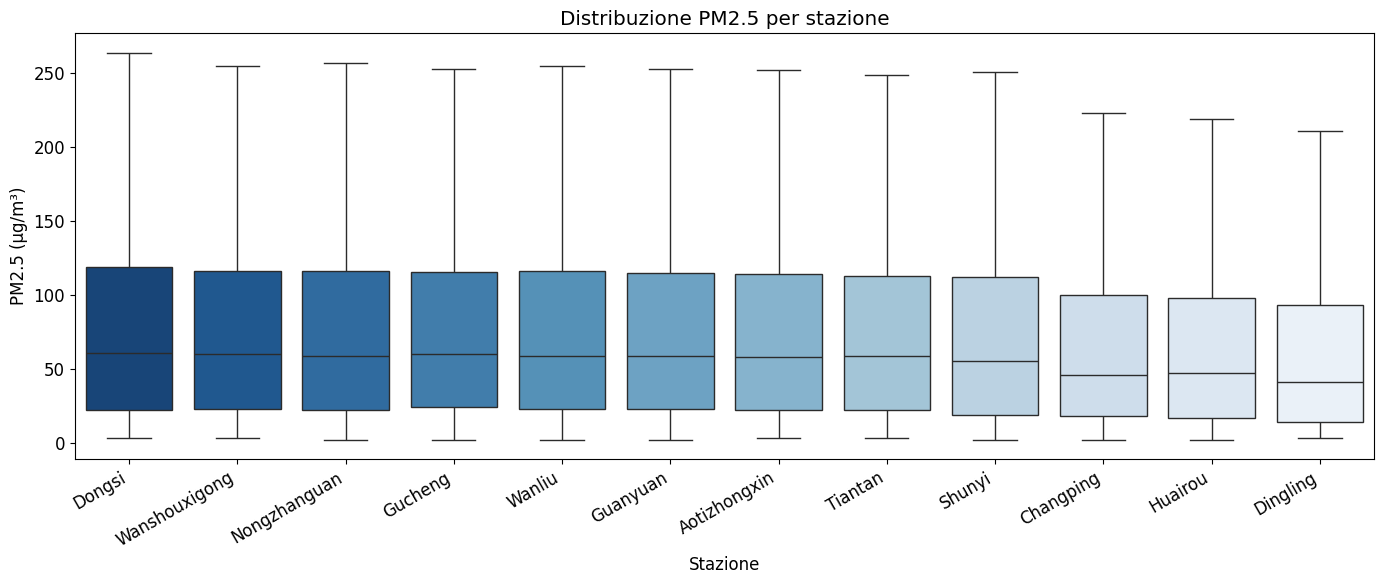

,mean,median,std,count
station,,,,
Dongsi,86.2,61.0,86.6,34314
Wanshouxigong,85.0,60.0,86.0,34368
Nongzhanguan,84.8,59.0,86.2,34436
Gucheng,83.9,60.0,82.8,34418
Wanliu,83.4,59.0,81.9,34682
Guanyuan,82.9,59.0,80.9,34448
Aotizhongxin,82.8,58.0,82.1,34139
Tiantan,82.2,59.0,80.9,34387
Shunyi,79.5,55.0,81.2,34151


In [11]:
station_order = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='station', y='PM2.5', order=station_order, palette='Blues_r', showfliers=False)
plt.title('Distribuzione PM2.5 per stazione')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Stazione')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df.groupby('station')['PM2.5'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False).round(1)

Le stazioni hanno valori medi molto simili tra loro: l'inquinamento da PM2.5 è distribuito in modo relativamente uniforme su scala urbana a Pechino. Questo indica che probabilmente la stazione di rilevamento non sarà un predittore importante.

### 2.8 Correlazione tra le feature

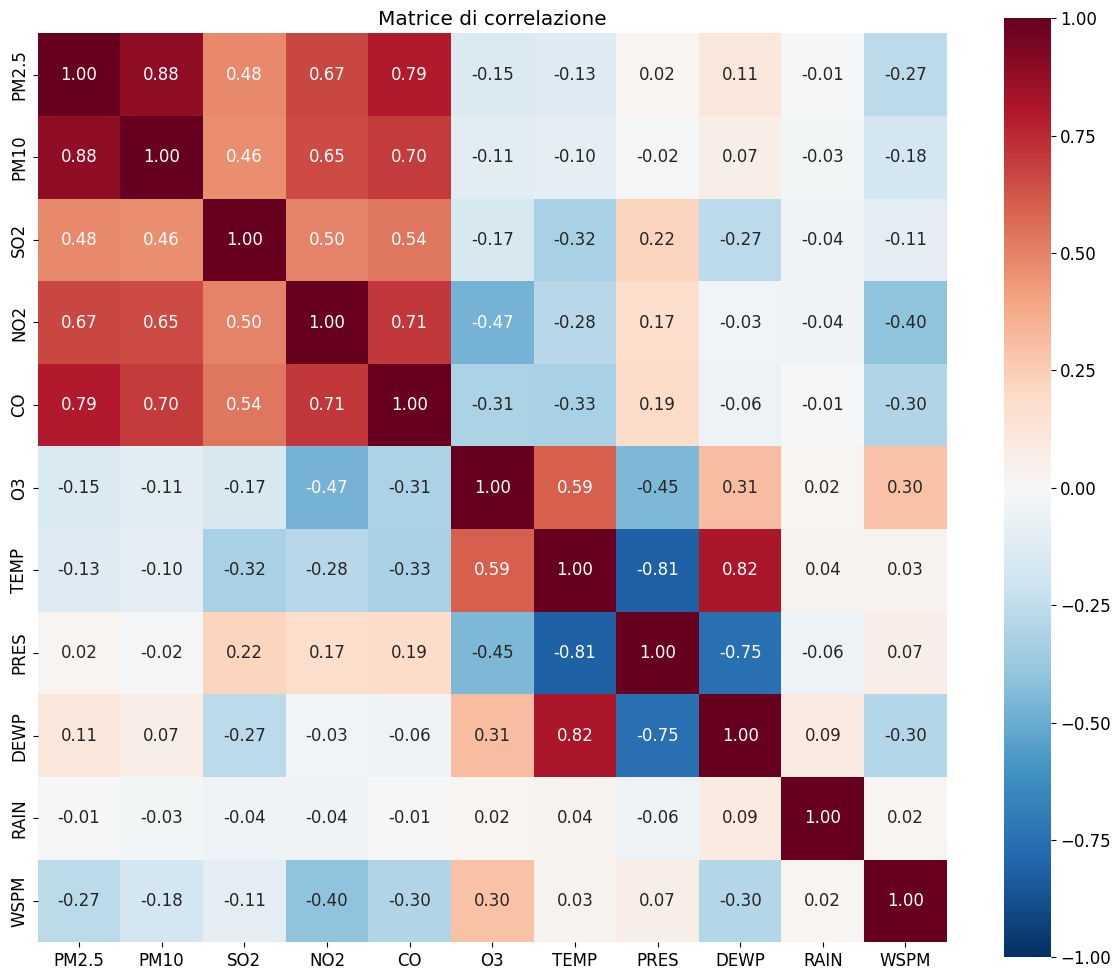

In [12]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', square=True, center=0, vmin=-1, vmax=1)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

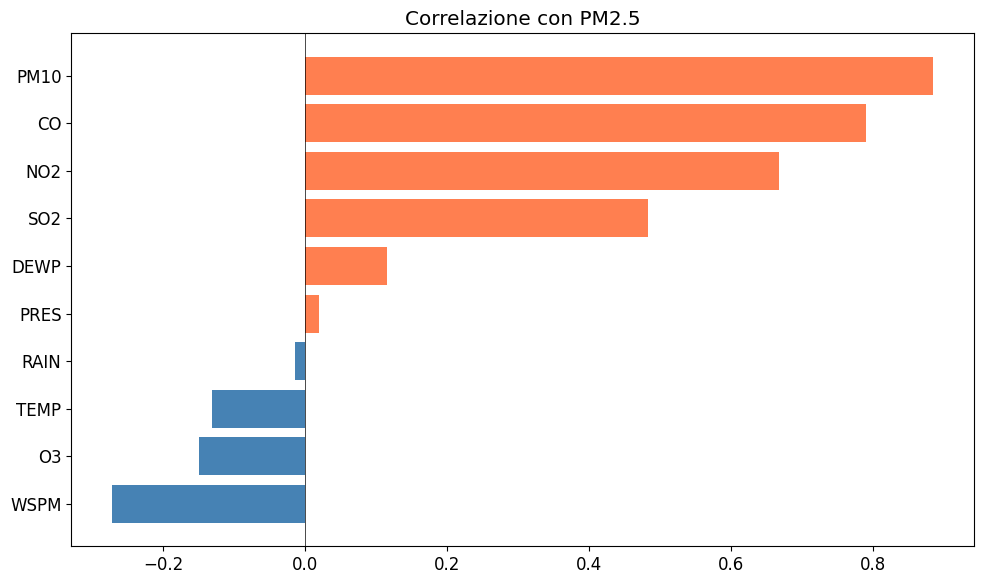

In [13]:
corr_pm25 = corr['PM2.5'].drop('PM2.5').sort_values()

colors = ['steelblue' if v < 0 else 'coral' for v in corr_pm25.values]

plt.figure(figsize=(10, 6))
plt.barh(corr_pm25.index, corr_pm25.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Correlazione con PM2.5')
plt.tight_layout()
plt.show()

Le correlazioni più forti con il PM2.5 sono:

- **CO e PM10** (> 0.7): stesse fonti di emissione, co-emessi con il PM2.5.
- **NO2 e SO2**: correlazione positiva.
- **O3**: correlazione negativa.
- **WSPM**: negativa, il vento disperde il particolato.
- **TEMP**: negativa, in inverno convergono riscaldamento a carbone e inversioni termiche.

### 2.9 Distribuzione di PM2.5 rispetto alle variabili predittive

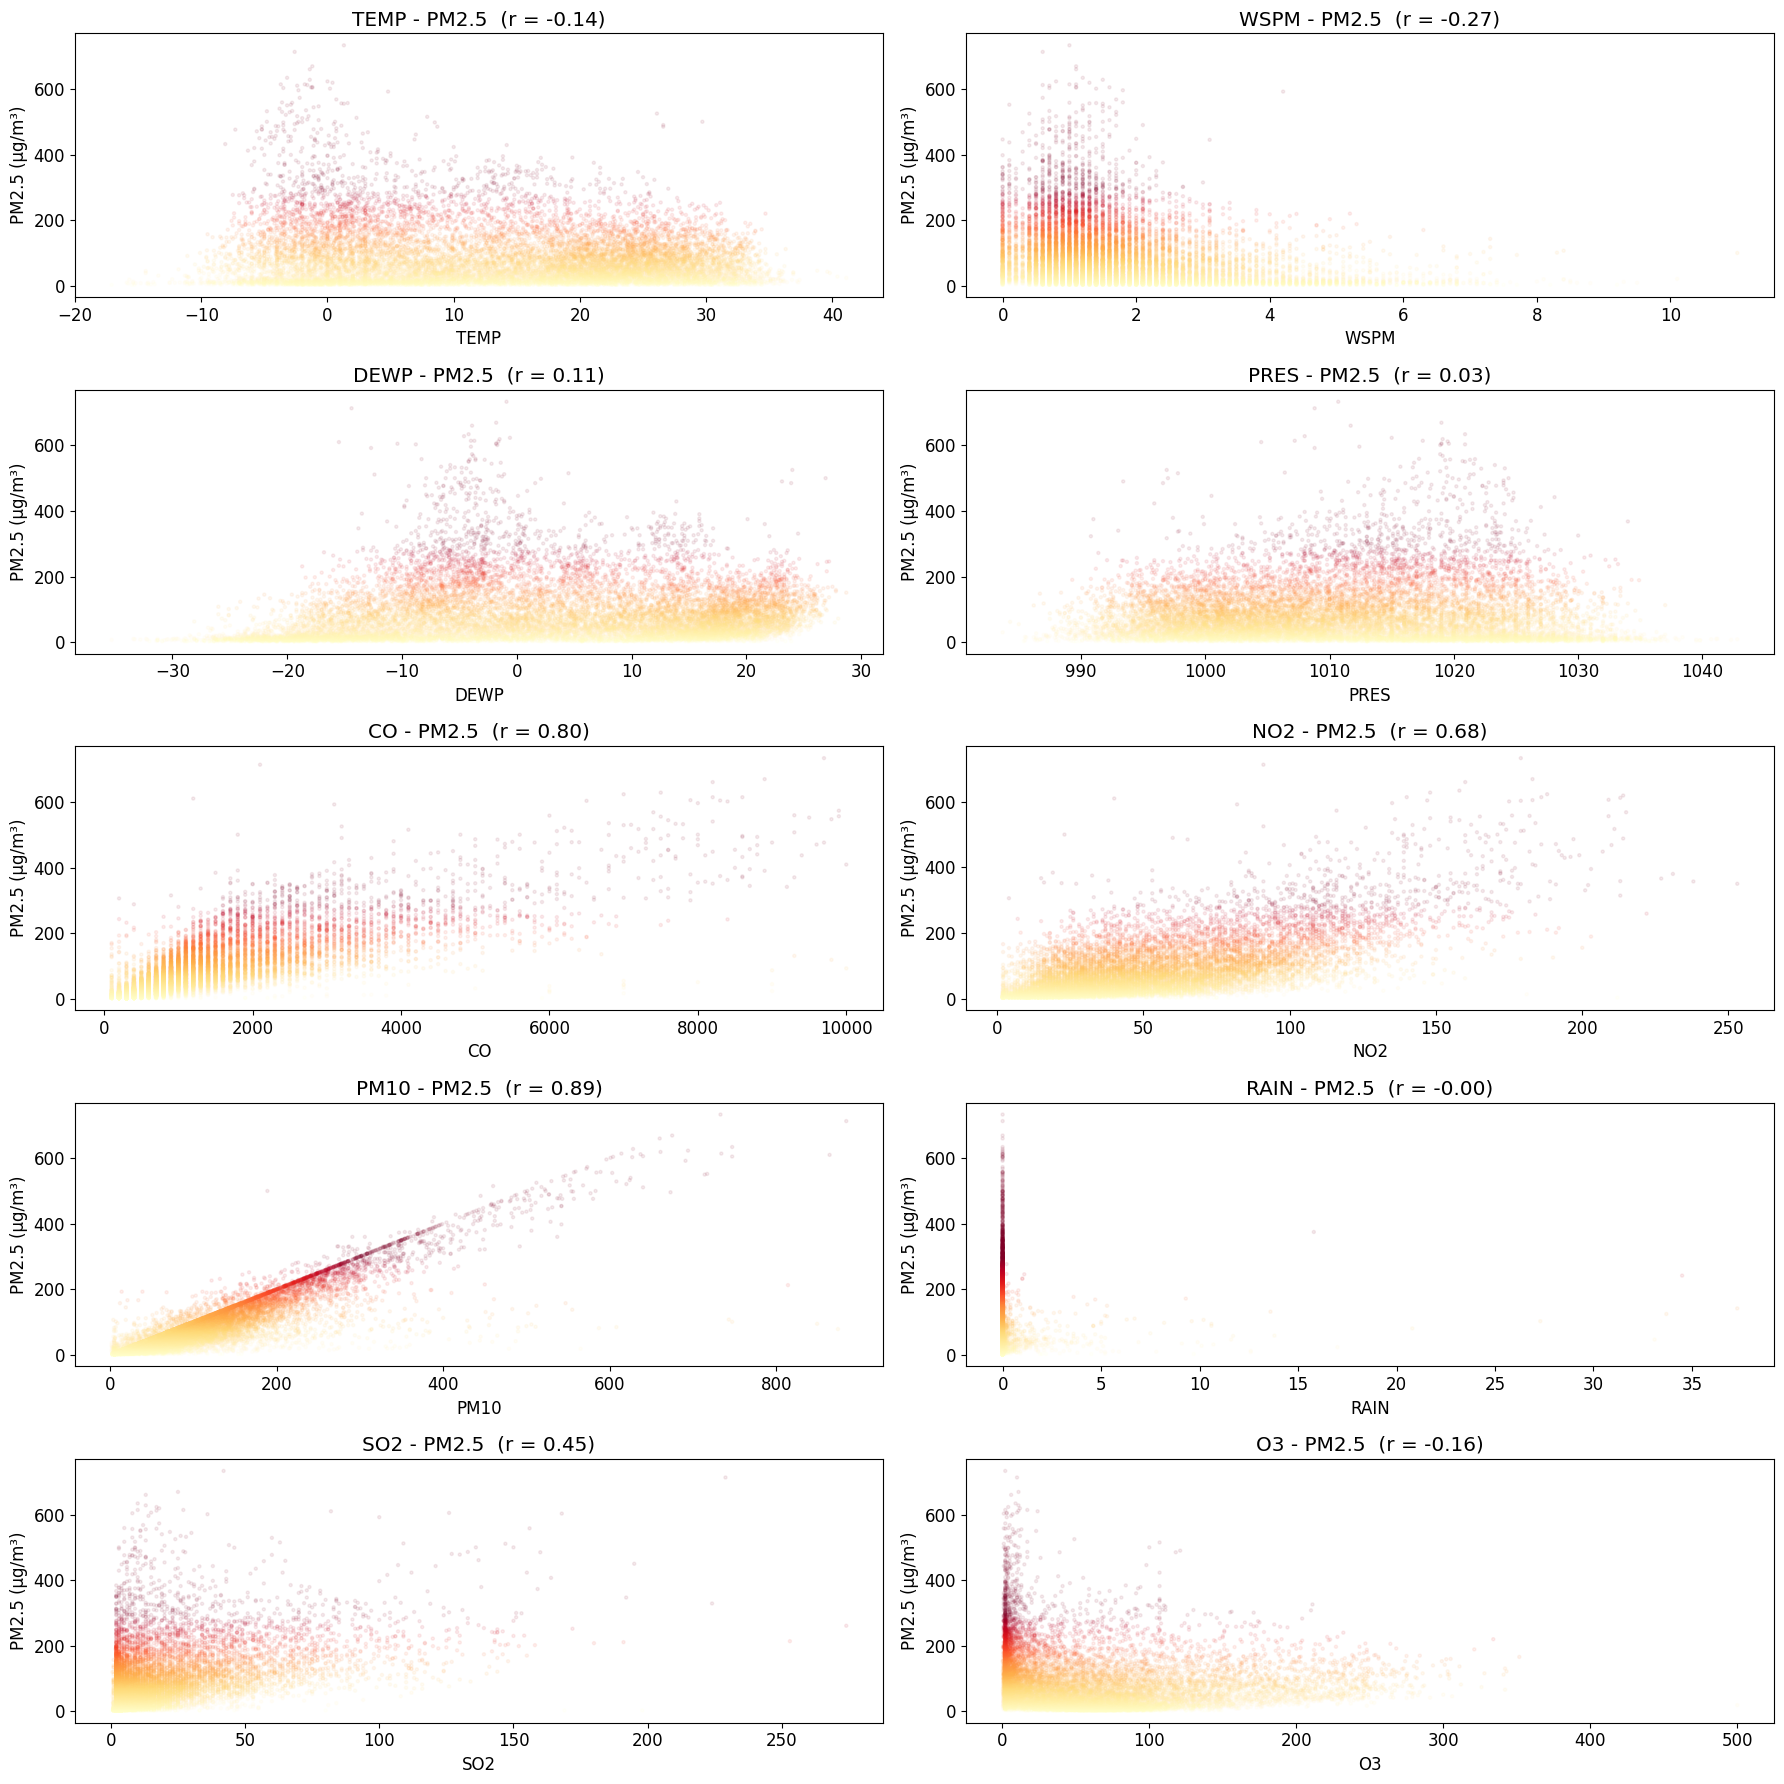

In [14]:
sample = df.dropna(subset=['PM2.5']).sample(n=15000, random_state=SEED)

scatter_vars = ['TEMP', 'WSPM', 'DEWP', 'PRES', 'CO', 'NO2', "PM10", "RAIN", "SO2", "O3"]

fig, axes = plt.subplots(5, 2, figsize=(18, 18))

for ax, var in zip(axes.flat, scatter_vars):
    r = sample['PM2.5'].corr(sample[var])
    sc = ax.scatter(sample[var], sample['PM2.5'], c=sample['PM2.5'], cmap='YlOrRd', alpha=0.08, s=5, vmax=300)
    ax.set_xlabel(var)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{var} - PM2.5  (r = {r:.2f})')

plt.tight_layout()
plt.show()

Tra gli inquinanti, PM10 risulta il predittore più forte con una correlazione di 0.88: la relazione è quasi lineare, a conferma che i due particolati condividono le stesse sorgenti di emissione. L'ozono invece mostra una correlazione negativa (-0.16).

Per le feature meteorologiche, la velocità del vento è la variabile più rilevante (-0.27): venti forti favoriscono la dispersione del particolato. La temperatura (-0.14) riflette l'effetto dei sistemi di riscaldamento, mentre pressione (0.04) e pioggia (-0.02) mostrano correlazioni trascurabili.

## 3. Preparazione dei dati

### 3.1 Gestione valori mancanti

I NaN sono causati da guasti dei sensori e rappresentano meno del 5% dei dati. Data la bassa percentuale, vengono rimosse le righe con valori mancanti.

In [15]:
df_model = df.copy()
before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)
print(f"Righe rimosse: {before - after}")
print(f"Righe rimaste: {after}")

Righe rimosse: 38600
Righe rimaste: 382168


### 3.2 Codifica ciclica

Diverse variabili nel dataset sono cicliche: l'ora del giorno, il mese e il giorno della settimana. La codifica numerica grezza non rispetta questa periodicità. La trasformazione in sin e cos risolve il problema, mappando ogni valore su una circonferenza dove gli estremi si toccano.

La direzione del vento viene trattata allo stesso modo: essendo una variabile categorica "circolare", la codifica sin/cos preserva la continuità tra direzioni adiacenti.

Si estrae inoltre un flag binario `is_weekend` per distinguere i giorni feriali dai festivi.

In [16]:
# Giorno della settimana e weekend
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)

# Codifica ciclica variabili temporali
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['dayofweek'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['dayofweek'] / 7)

# Codifica ciclica direzione del vento
wd_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wd_rad = np.deg2rad(df_model['wd'].map(wd_to_deg))
df_model['wd_sin'] = np.sin(wd_rad)
df_model['wd_cos'] = np.cos(wd_rad)

# Rimozione delle colonne originali
df_model.drop(columns=['hour', 'month', 'dayofweek', 'day', 'weekday', 'wd'], inplace=True)

### 3.3 Rimozione valori anomali

Valori di PM2.5 > 500 µg/m³ corrispondono a eventi eccezionali o a malfunzionamenti dei sensori. Sono rari e possono distorcere i modelli lineari.

In [17]:
before = len(df_model)
df_model = df_model[df_model['PM2.5'] <= 500].reset_index(drop=True)
after = len(df_model)
print(f"Righe rimosse: {before - after:,}")
print(f"Righe rimaste: {after}")

Righe rimosse: 750
Righe rimaste: 381418


### 3.4 Esclusione della feature PM10

PM10 ha una correlazione di ~0.9 con il PM2.5 perché il PM2.5 è fisicamente un sottoinsieme del PM10. Includere PM10 come feature renderebbe la predizione banale: il modello si appoggerebbe quasi interamente su di esso ignorando gli altri predittori.

In [18]:
pm10_saved = df_model['PM10'].copy()
df_model.drop(columns=['PM10'], inplace=True)

### 3.5 Split temporale

Viene effettuato uno split temporale: il training set comprende i dati fino al 2016-09-01, il test set gli ultimi ~6 mesi. In un problema con struttura temporale, uno split casuale causerebbe data leakage perché il modello vedrebbe dati futuri durante il training.

In [19]:
split_date = pd.Timestamp('2016-09-01')
train_mask = df_model['datetime'] < split_date
test_mask = ~train_mask

print(f"Train: {train_mask.sum()} righe")
print(f"Test:  {test_mask.sum()} righe")

Train: 333282 righe
Test:  48136 righe


### 3.6 Target encoding

Per la stazione viene utilizzato il target encoding: ogni stazione viene sostituita con la media storica del PM2.5. La media è calcolata solo sul training set per evitare data leakage.

In [20]:
station_mean = (
    df_model.loc[train_mask]
    .groupby('station')['PM2.5']
    .mean()
)

df_model['station_target_enc'] = df_model['station'].map(station_mean)
df_model.drop(columns=['station'], inplace=True)

### 3.7 Preparazione finale

Il target `PM2.5` viene separato dalle feature predittive. Le colonne `datetime` e `year` vengono rimosse: la prima è una colonna di appoggio non informativa, la seconda è già rappresentata indirettamente dalle feature cicliche del mese.

Il dataset viene infine suddiviso in training e test set rispettando l'ordine temporale, per evitare data leakage.

In [21]:
# Target e feature
y = df_model['PM2.5']

# Colonne da rimuovere
drop_cols = ['PM2.5', 'datetime', 'year']

X = df_model.drop(columns=drop_cols)

# Split finale
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]
pm10_train = pm10_saved[train_mask]
pm10_test = pm10_saved[test_mask]

# Info
print(f"Righe Train set: {X_train.shape[0]}")
print(f"Righe Test set: {X_test.shape[0]}")
print(f"Feature: {X.shape[1]}\n")

X_train.info(verbose=False, memory_usage='deep')
X_train.head(1)

Righe Train set: 333282
Righe Test set: 48136
Feature: 19

<class 'pandas.core.frame.DataFrame'>
Index: 333282 entries, 0 to 377343
Columns: 19 entries, SO2 to station_target_enc
dtypes: float64(18), int64(1)
memory usage: 50.9 MB


,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,wd_sin,wd_cos,station_target_enc
0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,0.5,0,0.0,1.0,1.0,6.123234e-17,-0.433884,-0.900969,1.0,6.123234e-17,68.919348


## 4. Modelli di Regressione

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = [] # lista dei risultati

tscv = TimeSeriesSplit(n_splits=5)

### 4.1 Funzione di valutazione

Viene definita una funzione unica di valutazione che calcola le principali metriche di regressione.

In [23]:
def evaluate_model(X, y, model, name=''):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    rel_error = mae / np.mean(y)

    print(f"{name}:")
    print(f"\tRMSE:\t\t\t{rmse:.3f}")
    print(f"\tMAE:\t\t\t{mae:.3f}")
    print(f"\tRelative error:\t\t{rel_error:.3f}")
    print(f"\tR-2 coefficient:\t{r2:.3f}\n")

    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'Relative Error': rel_error, 'R2': r2}

### 4.2 Nested Cross Validation
La nested cross-validation avvolge la ricerca degli iperparametri in un loop esterno di validazione: per ogni fold esterno, la GridSearch viene ri-eseguita indipendentemente sul training set di quel fold e valutata sul fold di test. Il risultato è una stima più affidabile delle performance reali del modello, poiché la selezione degli iperparametri e la valutazione avvengono sempre su dati separati. La deviazione standard indica la stabilità della stima tra i fold.

In [24]:
def nested_cv_score(X, y, search, name=''):
    scores = cross_val_score(search, X, y, cv=tscv, scoring='r2', n_jobs=-1)
    print(f"{name} — Nested CV R²: {scores.mean():.3f} ± {scores.std():.3f}")
    return {'model': name, 'Nested CV R2 mean': scores.mean(), 'Nested CV R2 std': scores.std()}

### 4.3 DummyRegressor

Il primo modello di riferimento è un DummyRegressor, che predice sempre la media del PM2.5 calcolata sul training set, ignorando completamente tutte le feature disponibili.

Questo modello non utilizza alcuna informazione predittiva ed è utile come baseline: qualsiasi modello più avanzato deve necessariamente ottenere prestazioni migliori. In questo caso, il valore di R² è circa 0, poiché non spiega alcuna variabilità del target.

In [25]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

%time dummy.fit(X_train, y_train)

CPU times: user 580 μs, sys: 0 ns, total: 580 μs
Wall time: 604 μs


DummyRegressor()

In [26]:
evaluate_model(X_train, y_train, dummy, 'DummyRegressor - Train')
results.append(evaluate_model(X_test, y_test, dummy, 'DummyRegressor - Test'))

DummyRegressor - Train:
	RMSE:			74.486
	MAE:			55.918
	Relative error:		0.728
	R-2 coefficient:	0.000

DummyRegressor - Test:
	RMSE:			93.921
	MAE:			69.927
	Relative error:		0.777
	R-2 coefficient:	-0.020



Il modello produce un errore elevato e un R² prossimo a zero. Questo conferma che la semplice media storica del PM2.5 non è sufficiente a catturare il fenomeno e rappresenta quindi una soglia minima di prestazione per qualsiasi modello successivo.

### 4.4 Regressione Lineare

La regressione lineare rappresenta il primo modello “reale”.

Poiché le variabili hanno scale molto diverse, si utilizza una Pipeline con StandardScaler per standardizzare i dati prima della regressione. Il modello non include alcuna regolarizzazione, così da valutare la capacità della semplice relazione lineare tra feature e target.

In [27]:
from sklearn.linear_model import LinearRegression

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

nested_cv_score(X_train, y_train, linear, 'Regressione Lineare')
%time linear.fit(X_train, y_train)

Regressione Lineare — Nested CV R²: 0.709 ± 0.011
CPU times: user 248 ms, sys: 88.2 ms, total: 336 ms
Wall time: 161 ms


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [28]:
evaluate_model(X_train, y_train, linear, 'Regressione Lineare - Train')
results.append(evaluate_model(X_test, y_test, linear, 'Regressione Lineare - Test'))

Regressione Lineare - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Regressione Lineare - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.5 Lasso Regression

Il Lasso aggiunge una penalità L1 ai coefficienti, che può azzerarli completamente effettuando una selezione automatica delle variabili. L'iperparametro alpha controlla l'intensità della regolarizzazione e viene selezionato con GridSearchCV.

In [29]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.1, 0.5, 1]}

gs_lasso = GridSearchCV(lasso, grid, cv=tscv)
nested_cv_score(X_train, y_train, gs_lasso, 'Lasso')
%time gs_lasso.fit(X_train, y_train)

Lasso — Nested CV R²: 0.709 ± 0.011
CPU times: user 8.93 s, sys: 9.5 s, total: 18.4 s
Wall time: 9.14 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso())]),
             param_grid={'lasso__alpha': [0.1, 0.5, 1]})

In [30]:
evaluate_model(X_train, y_train, gs_lasso, 'Lasso - Train')
results.append(evaluate_model(X_test, y_test, gs_lasso, 'Lasso - Test'))

Lasso - Train:
	RMSE:			40.009
	MAE:			27.636
	Relative error:		0.360
	R-2 coefficient:	0.711

Lasso - Test:
	RMSE:			42.643
	MAE:			30.002
	Relative error:		0.333
	R-2 coefficient:	0.790



#### Analisi dei coefficienti di Lasso

In [31]:
print(f"Alpha ottimale: {gs_lasso.best_params_['lasso__alpha']}")

coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print("\nFeature escluse:")
print(zero)

Alpha ottimale: 0.1

Feature escluse:
TEMP       -0.0
hour_cos   -0.0
dow_sin     0.0
dtype: float64


Il GridSearchCV ha selezionato alpha = 0.05.
Lasso ha azzerato i coefficienti delle feature `TEMP`, `hour_cos` e `dow_sin`, escludendole dal modello.

### 4.6 Ridge Regression

La Ridge aggiunge una penalità L2 ai coefficienti: li riduce uniformemente senza azzerarli, rendendola più stabile in presenza di multicollinearità. Anche in questo caso, alpha viene selezionato con GridSearchCV.

In [32]:
from sklearn.linear_model import Ridge

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10]}

gs_ridge = GridSearchCV(ridge, grid, cv=tscv)
nested_cv_score(X_train, y_train, gs_ridge, 'Ridge')
%time gs_ridge.fit(X_train, y_train)

Ridge — Nested CV R²: 0.709 ± 0.011
CPU times: user 1.9 s, sys: 3.19 s, total: 5.1 s
Wall time: 2.55 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.1, 1, 10]})

In [33]:
print(f"Alpha ottimale: {gs_ridge.best_params_['ridge__alpha']}\n")

evaluate_model(X_train, y_train, gs_ridge, 'Ridge - Train')
results.append(evaluate_model(X_test, y_test, gs_ridge, 'Ridge - Test'))

Alpha ottimale: 0.1

Ridge - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Ridge - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.7 ElasticNet

L'ElasticNet combina le penalità L1 e L2, controllate dai parametri alpha e l1_ratio. Questo permette sia la selezione delle feature (L1) sia la stabilità con variabili correlate (L2).

In [34]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])

grid = {
    'regr__alpha': [0.05, 0.1, 0.5],
    'regr__l1_ratio': [0.25, 0.5, 0.75]
}

gs_elasticnet = GridSearchCV(elasticnet, grid, cv=tscv, scoring='r2')
nested_cv_score(X_train, y_train, gs_elasticnet, 'ElasticNet')
%time gs_elasticnet.fit(X_train, y_train)

ElasticNet — Nested CV R²: 0.708 ± 0.011
CPU times: user 22.4 s, sys: 24.6 s, total: 47 s
Wall time: 24.3 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regr', ElasticNet())]),
             param_grid={'regr__alpha': [0.05, 0.1, 0.5],
                         'regr__l1_ratio': [0.25, 0.5, 0.75]},
             scoring='r2')

In [35]:
print(f"Alpha ottimale:    {gs_elasticnet.best_params_['regr__alpha']}")
print(f"L1 ratio ottimale: {gs_elasticnet.best_params_['regr__l1_ratio']}\n")

evaluate_model(X_train, y_train, gs_elasticnet, 'Elastic Net - Train')
results.append(evaluate_model(X_test, y_test, gs_elasticnet, 'Elastic Net - Test'))

Alpha ottimale:    0.05
L1 ratio ottimale: 0.75

Elastic Net - Train:
	RMSE:			40.071
	MAE:			27.501
	Relative error:		0.358
	R-2 coefficient:	0.711

Elastic Net - Test:
	RMSE:			42.423
	MAE:			29.575
	Relative error:		0.329
	R-2 coefficient:	0.792



### 4.8 Regressione Polinomiale

La regressione polinomiale espande le feature con termini quadratici e prodotti tra coppie di variabili, permettendo di catturare relazioni non lineari. Si combina con Ridge per regolarizzare i coefficienti aggiuntivi e ridurre 
l'overfitting.

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [500, 1000, 1500]}

gs_poly = GridSearchCV(poly_ridge, grid, cv=tscv, scoring='r2', n_jobs=-1)
nested_cv_score(X_train, y_train, linear, 'Regressione Polinomiale')
%time gs_poly.fit(X_train, y_train)

Regressione Polinomiale — Nested CV R²: 0.709 ± 0.011
CPU times: user 1.49 s, sys: 222 ms, total: 1.71 s
Wall time: 9.3 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('ridge', Ridge())]),
             n_jobs=-1, param_grid={'ridge__alpha': [500, 1000, 1500]},
             scoring='r2')

In [37]:
print(f"Alpha ottimale: {gs_poly.best_params_['ridge__alpha']}")

evaluate_model(X_train, y_train, gs_poly, 'Polinomiale - Train')
results.append(evaluate_model(X_test, y_test, gs_poly, 'Polinomiale - Test'))

Alpha ottimale: 500
Polinomiale - Train:
	RMSE:			34.037
	MAE:			22.661
	Relative error:		0.295
	R-2 coefficient:	0.791

Polinomiale - Test:
	RMSE:			41.777
	MAE:			26.187
	Relative error:		0.291
	R-2 coefficient:	0.798



### 4.9 Random Forest

Il Random Forest combina più alberi decisionali, ognuno addestrato su un sottoinsieme casuale dei dati e delle feature. Cattura naturalmente non linearità e interazioni senza bisogno di feature engineering esplicito.

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    'regr__n_estimators':      [200, 300],
    'regr__max_depth':         [8, 10, 12, 15],
    'regr__min_samples_split': [5, 10, 15],
    'regr__min_samples_leaf':  [5, 10, 15],
    'regr__max_features':      ['sqrt'],
    'regr__max_samples':       [0.5, 0.6, 0.7],
}

rs_rf = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)
nested_cv_score(X_train, y_train, rs_rf, 'Random Forest')
%time rs_rf.fit(X_train, y_train)

Random Forest — Nested CV R²: 0.831 ± 0.020
CPU times: user 1min 25s, sys: 831 ms, total: 1min 26s
Wall time: 14min 16s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regr',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'regr__max_depth': [8, 10, 12, 15],
                                        'regr__max_features': ['sqrt'],
                                        'regr__max_samples': [0.5, 0.6, 0.7],
                                        'regr__min_samples_leaf': [5, 10, 15],
                                        'regr__min_samples_split': [5, 10, 15],
                                        'regr__n_estimators': [200, 300]},
                   random_state=42, scoring='r2')

In [39]:
print(f"Migliori iperparametri: {rs_rf.best_params_}\n")

evaluate_model(X_train, y_train, rs_rf, 'Random Forest - Train')
results.append(evaluate_model(X_test, y_test, rs_rf, 'Random Forest - Test'))

{'regr__n_estimators': 300, 'regr__min_samples_split': 10, 'regr__min_samples_leaf': 5, 'regr__max_samples': 0.7, 'regr__max_features': 'sqrt', 'regr__max_depth': 15}
Random Forest - Train:
	RMSE:			24.197
	MAE:			15.959
	Relative error:		0.208
	R-2 coefficient:	0.894

Random Forest - Test:
	RMSE:			38.834
	MAE:			23.847
	Relative error:		0.265
	R-2 coefficient:	0.826



### 4.10 XGBoost

XGBoost è un algoritmo di gradient boosting che costruisce alberi in sequenza, dove ogni albero corregge gli errori del precedente. È generalmente il modello più performante per dati tabulari. Si usa RandomizedSearchCV dato il maggior numero di iperparametri.

In [40]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        n_estimators=700
    ))
])

param_dist = {
    'xgb__max_depth':        [4, 5, 6],
    'xgb__learning_rate':    [0.03, 0.05, 0.08],
    'xgb__subsample':        [0.4, 0.5, 0.6],
    'xgb__colsample_bytree': [0.5, 0.6, 0.7],
    'xgb__reg_alpha':        [10, 20, 30],
    'xgb__reg_lambda':       [50, 100, 200],
    'xgb__min_child_weight': [30, 50, 100],
    'xgb__gamma':            [2, 5, 10],
}

rs_xgb = RandomizedSearchCV(xgb, param_dist, n_iter=10, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)
nested_cv_score(X_train, y_train, rs_xgb, 'XGBoost')
%time rs_xgb.fit(X_train, y_train)

XGBoost — Nested CV R²: 0.844 ± 0.020
CPU times: user 15 s, sys: 242 ms, total: 15.2 s
Wall time: 2min 59s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('xgb',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metri...
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'xgb__colsample_bytree': [0.5, 0.6,
                                                                  0.7],
                                        'xgb__gamma': [2, 5, 10],
                                        'xgb__learning_rate': [0.03, 0.05,
                                                               0.08],
                                        'xgb__max_depth': [4, 5, 6],
                                        'xgb__min_child_weight': [30, 50, 100],
                                        'xgb__reg_alpha': [10, 20, 30],
                                        'xgb__reg_lambda': [50, 100, 200],
                                        'xgb__subsample': [0.4, 0.5, 0.6]},
                   random_state=42, scoring='r2')

In [41]:
print(f"Migliori iperparametri: {rs_xgb.best_params_}\n")

evaluate_model(X_train, y_train, rs_xgb, 'XGBoost - Train')
results.append(evaluate_model(X_test, y_test, rs_xgb, 'XGBoost - Test'))

{'xgb__subsample': 0.5, 'xgb__reg_lambda': 50, 'xgb__reg_alpha': 10, 'xgb__min_child_weight': 50, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__gamma': 10, 'xgb__colsample_bytree': 0.7}
XGBoost - Train:
	RMSE:			24.976
	MAE:			16.438
	Relative error:		0.214
	R-2 coefficient:	0.888

XGBoost - Test:
	RMSE:			39.347
	MAE:			23.992
	Relative error:		0.267
	R-2 coefficient:	0.821



### 4.11 Confronto

In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')
results_df = results_df.round(3)
results_df.sort_values('R2', ascending=False)

,RMSE,MAE,Relative Error,R2
model,,,,
Random Forest - Test,38.834,23.847,0.265,0.826
XGBoost - Test,39.347,23.992,0.267,0.821
Polinomiale - Test,41.777,26.187,0.291,0.798
Elastic Net - Test,42.423,29.575,0.329,0.792
Lasso - Test,42.643,30.002,0.333,0.790
Regressione Lineare - Test,42.725,30.160,0.335,0.789
Ridge - Test,42.725,30.160,0.335,0.789
DummyRegressor - Test,93.921,69.927,0.777,-0.020


Random Forest ottiene le performance migliori (R² = 0.826), seguito a breve distanza da XGBoost (R² = 0.821).

La regressione polinomiale (R² = 0.798) migliora rispetto ai modelli lineari puri, confermando la presenza di relazioni non lineari nel dataset. ElasticNet, Lasso e Ridge ottengono risultati quasi identici (R² ≈ 0.789–0.792), a indicare che la regolarizzazione non porta vantaggi significativi rispetto alla regressione lineare base su questo dataset.

L'errore relativo di Random Forest pari a 0.265 indica che in media il modello sbaglia del 26.5% rispetto al valore reale, un risultato accettabile considerando la forte variabilità e la presenza di picchi estremi nel dataset.

## 5. Analisi e interpretazione dei modelli migliori

In questa sezione vengono analizzati nel dettaglio i modelli migliori per ciascuna categoria: ElasticNet per i modelli lineari, la regressione polinomiale e Random Forest per i modelli ad albero decisionale. Per i modelli lineari e polinomiali si esaminano i coefficienti delle feature, mentre per i modelli ad albero si analizza la struttura dei primi nodi per individuare le variabili più rilevanti nella predizione del PM2.5.

### 5.1 Coefficienti della regressione lineare (ElasticNet)

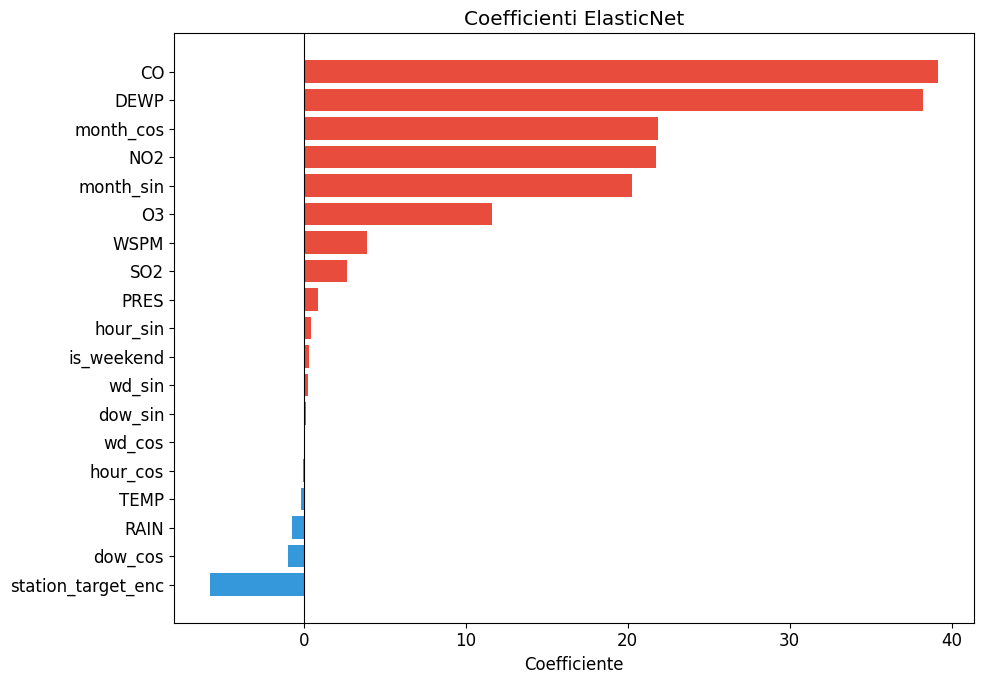

feature più positive:
month_sin    20.280968
NO2          21.718837
month_cos    21.855472
DEWP         38.209821
CO           39.140024
dtype: float64

feature più negative:
station_target_enc   -5.769659
dow_cos              -0.986967
RAIN                 -0.697896
TEMP                 -0.194909
hour_cos             -0.024211
dtype: float64


In [43]:
coef = pd.Series(
    gs_elasticnet.best_estimator_['regr'].coef_,
    index=X_train.columns
).sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]

plt.figure(figsize=(10, 7))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficienti ElasticNet')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"feature più positive:\n{coef.tail(5)}\n")
print(f"feature più negative:\n{coef.head(5)}")

Tra i coefficienti positivi, CO e DEWP sono i più influenti, seguiti da NO2 e dalle componenti cicliche del mese (month_sin, month_cos), che confermano la forte stagionalità del PM2.5 già osservata nell'analisi esplorativa. Sorprende il coefficiente positivo di O3 e WSPM, che negli scatter plot mostravano una correlazione negativa: in un modello lineare multivariato le correlazioni tra feature possono alterare il segno dei coefficienti (multicollinearità).

Sul fronte negativo, station_target_enc ha il coefficiente più grande in valore assoluto (-5.6), indicando che stazioni con una media storica di PM2.5 più alta tendono paradossalmente a predire valori più bassi nel modello lineare, probabilmente per effetti di compensazione con le altre feature. TEMP e RAIN mostrano coefficienti negativi contenuti, coerenti con il loro ruolo di fattori di dispersione del particolato.

### 5.2 Coefficienti della regressione polinomiale

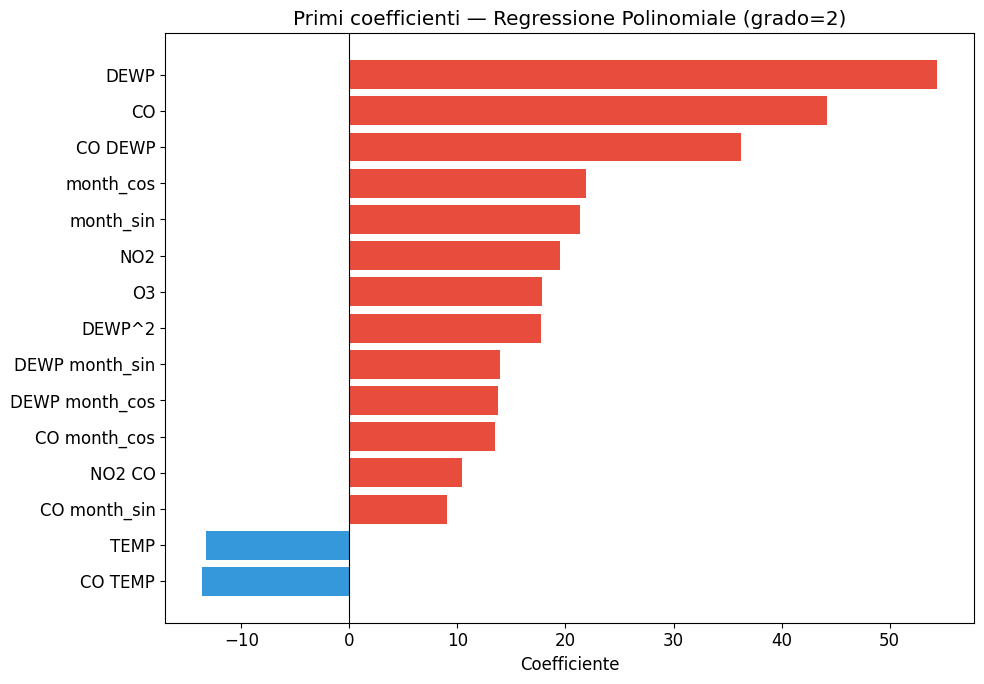

Numero totale di feature polinomiali: 209

feature più positive:
month_sin    21.368473
month_cos    21.906367
CO DEWP      36.224319
CO           44.192603
DEWP         54.414344
dtype: float64

feature più negative:
CO TEMP     -13.661776
TEMP        -13.244025
CO^2         -6.842794
TEMP PRES    -6.813093
SO2 DEWP     -6.482986
dtype: float64


In [44]:
poly_features = gs_poly.best_estimator_['poly'].get_feature_names_out(X_train.columns)
coef_poly = pd.Series(
    gs_poly.best_estimator_['ridge'].coef_,
    index=poly_features
)

top15 = coef_poly.abs().sort_values(ascending=False).head(15)
top15_coef = coef_poly[top15.index].sort_values()
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top15_coef]

plt.figure(figsize=(10, 7))
plt.barh(top15_coef.index, top15_coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Primi coefficienti — Regressione Polinomiale (grado=2)')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"Numero totale di feature polinomiali: {len(poly_features)}")
print(f"\nfeature più positive:\n{coef_poly.sort_values().tail(5)}")
print(f"\nfeature più negative:\n{coef_poly.sort_values().head(5)}")

La regressione polinomiale di grado 2 genera 209 feature a partire dalle 19 originali, includendo termini quadratici e interazioni tra coppie di variabili.

Tra i coefficienti più rilevanti emergono DEWP e CO come variabili singole più influenti. La novità rispetto al modello lineare è la comparsa di termini di interazione: CO×DEWP ha il terzo coefficiente più alto, suggerendo che la combinazione di alta concentrazione di CO e alto punto di rugiada amplifica il PM2.5 in modo non lineare. Analogamente, le interazioni CO×month_sin e DEWP×month_sin catturano l'effetto stagionale combinato con gli inquinanti.

Sul fronte negativo, TEMP e CO×TEMP hanno i coefficienti più grandi in valore assoluto: temperature elevate associate ad alte concentrazioni di CO tendono a ridurre il PM2.5 stimato, probabilmente per effetto della convezione termica che favorisce la dispersione del particolato.

### 5.3 Analisi Random Forest

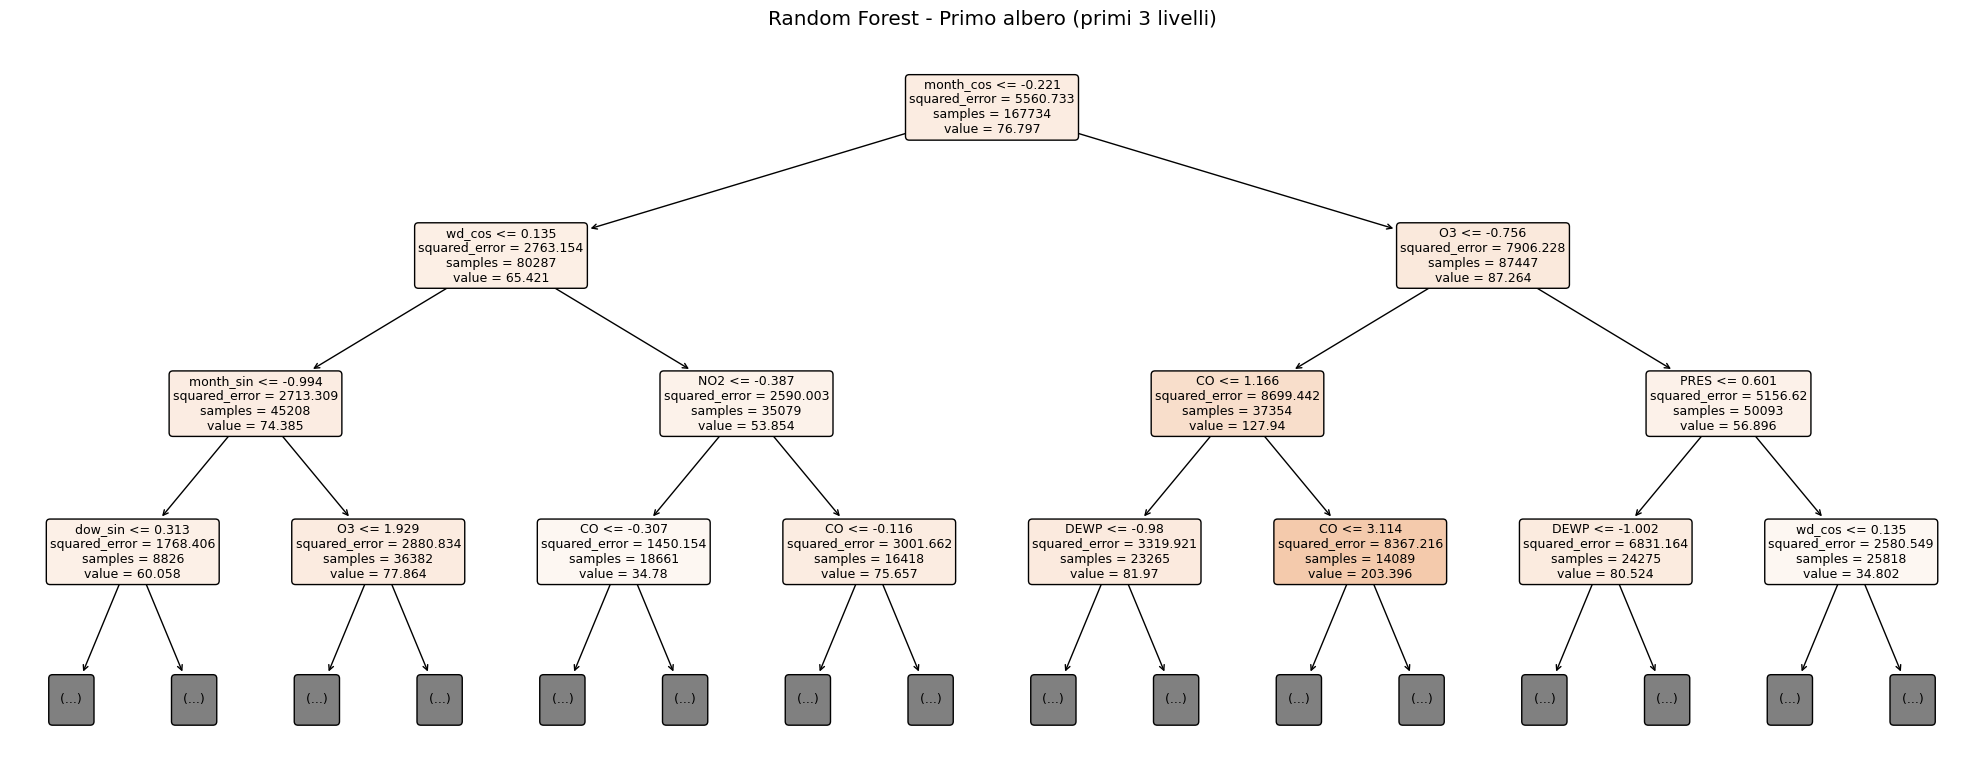

In [45]:
from sklearn.tree import plot_tree

singolo_albero = rs_rf.best_estimator_['regr'].estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(
    singolo_albero,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Random Forest - Primo albero (primi 3 livelli)')
plt.tight_layout()
plt.show()

Il primo albero del Random Forest effettua il primo split su `month_cos`, separando i mesi invernali (sinistra, PM2.5 medio = 65.7) da quelli estivi (destra, PM2.5 medio = 86.5), confermando la forte stagionalità già osservata nell'analisi esplorativa.

Al secondo livello compaiono variabili diverse nei due rami: a sinistra la direzione del vento (`wd_cos`) e a destra il punto di rugiada (`DEWP`), che separa ulteriormente le condizioni atmosferiche favorevoli all'accumulo del particolato. Al terzo livello emerge `CO` come variabile discriminante.

Il nodo in basso a destra mostra il valore medio più alto (147.5 µg/m³), corrispondente a condizioni di mese invernale, punto di rugiada elevato e vento debole: esattamente le condizioni tipiche degli episodi acuti di smog a Pechino.

Va ricordato che si tratta di un singolo albero su centinaia: le variabili scelte e le soglie variano da albero ad albero, ed è la media di tutti che determina la predizione finale del modello.

## 6. Analisi del contributo dei gruppi di feature

In alcuni scenari reali può capitare di non disporre delle misurazioni degli inquinanti chimici, ad esempio in aree prive di sensori dedicati. Per valutare quanto sia possibile predire il PM2.5 in queste condizioni, si addestra XGBoost separatamente su due gruppi di feature, mantenendo fissi gli iperparametri trovati nella sezione 4.9.

I gruppi sono:
- **Inquinanti**: SO2, NO2, CO, O3
- **Temporali + Meteorologiche**: TEMP, PRES, DEWP, RAIN, WSPM, wd e le feature temporali cicliche

In [46]:
from sklearn.base import clone

X_train_pm10 = pd.concat([X_train, pm10_train.rename('PM10')], axis=1)
X_test_pm10  = pd.concat([X_test,  pm10_test.rename('PM10')],  axis=1)

feature_groups = {
    'Inquinanti': ['SO2', 'NO2', 'CO', 'O3'],
    'Temporali + Meteorologiche': ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                                   'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos',
                                   'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
                                   'is_weekend'],
    'Tutte + PM10': X_train_pm10.columns.tolist()
}

best_xgb = rs_xgb.best_estimator_['xgb']

for group_name, features in feature_groups.items():
    X_tr = X_train_pm10 if group_name == 'Tutte + PM10' else X_train
    X_te = X_test_pm10  if group_name == 'Tutte + PM10' else X_test
    model = Pipeline([('scaler', StandardScaler()), ('xgb', clone(best_xgb))])
    model.fit(X_tr[features], y_train)
    evaluate_model(X_tr[features], y_train, model, f'XGBoost - {group_name} - Train')
    evaluate_model(X_te[features], y_test, model, f'XGBoost - {group_name} - Test')

XGBoost - Inquinanti - Train:
	RMSE:			38.071
	MAE:			25.343
	Relative error:		0.330
	R-2 coefficient:	0.739

XGBoost - Temporali + Meteorologiche - Train:
	RMSE:			41.761
	MAE:			28.795
	Relative error:		0.375
	R-2 coefficient:	0.686

XGBoost - Tutte + PM10 - Train:
	RMSE:			16.921
	MAE:			10.922
	Relative error:		0.142
	R-2 coefficient:	0.948



I risultati confermano l'importanza relativa dei diversi gruppi di feature.

Il gruppo degli inquinanti (R² = 0.786 sul test) performa meglio del gruppo temporale e meteorologico (R² = 0.534), confermando che CO, NO2, SO2 e O3 sono i predittori più informativi. Il gruppo meteorologico ottiene comunque un R² = 0.534: in assenza di sensori chimici è quindi possibile stimare il PM2.5 con una certa approssimazione basandosi solo su temperatura, umidità e stagionalità.

Il modello con tutte le feature più PM10 raggiunge R² = 0.953, confermando quanto già osservato nell'analisi esplorativa (r = 0.88): PM10 è il predittore più potente per il PM2.5, motivo per cui era stato escluso per evitare che dominasse il modello a scapito delle altre variabili.

## 7. Classificazione
In un sistema di allerta per la qualità dell'aria non è sempre necessario conoscere il valore esatto di PM2.5, ma è sufficiente sapere in quale fascia di rischio rientra. Il problema viene quindi riformulato come classificazione multiclasse, assegnando ad ogni osservazione una delle 6 categorie dello standard AQI cinese in base alla concentrazione di PM2.5.


### 7.1 Definizione delle classi e distribuzione
Come già osservato durante l'analisi del dataset, le classi sono fortemente sbilanciate: la maggior parte delle ore rientra nella fascia "Buona" e "Moderata", mentre le classi più pericolose hanno pochi campioni. Per gestire questo sbilanciamento si usa `class_weight='balanced'` nei classificatori, che assegna pesi inversamente proporzionali alla frequenza di ogni classe.

In [47]:
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]
aqi_names = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
 
# Creazione target classificazione
y_train_class = pd.cut(y_train, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
y_test_class = pd.cut(y_test, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)

### 7.2 Funzione di valutazione
 
Si definisce una funzione unica per valutare i classificatori con accuracy e F1 macro (media non pesata tra le classi, che dà uguale importanza anche alle classi rare).

In [48]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
 
results_clf = []

tscv = TimeSeriesSplit(n_splits=5)
 
def evaluate_clf(X, y, model, name=''):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='macro')

    print(f"{name}:")
    print(f"\tAccuracy:\t{acc:.4f}")
    print(f"\tF1 Macro:\t{f1:.4f}\n")

    return {'model': name, 'Accuracy': acc, 'F1 Macro': f1}

### 7.3 Nested Cross Validation
Anche per la classificazione viene utilizzata la Nested Cross Validation.

In [49]:
def nested_cv_score_clf(X, y, search, name=''):
    scores = cross_val_score(search, X, y, cv=tscv, scoring='f1_macro', n_jobs=-1)
    print(f"{name} — Nested CV F1 macro: {scores.mean():.3f} ± {scores.std():.3f}")
    return {'model': name, 'Nested CV F1 mean': scores.mean(), 'Nested CV F1 std': scores.std()}

### 7.4 Perceptron

Il Perceptron è il più semplice classificatore lineare: aggiorna i pesi solo quando sbaglia una predizione, senza una funzione di loss continua. Viene incluso come ulteriore baseline lineare per confronto con LinearSVC e Logistic Regression.

In [50]:

from sklearn.linear_model import Perceptron

perc_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', Perceptron(class_weight='balanced', random_state=SEED, n_jobs=-1))
])

grid = {'clf__alpha': [0.0001, 0.001, 0.01]}

gs_perc_clf = GridSearchCV(perc_clf, grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
nested_cv_score_clf(X_train, y_train_class, gs_perc_clf, 'Perceptron')
%time gs_perc_clf.fit(X_train, y_train_class)

Perceptron — Nested CV F1 macro: 0.347 ± 0.026
CPU times: user 3.2 s, sys: 113 ms, total: 3.32 s
Wall time: 13.2 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        Perceptron(class_weight='balanced',
                                                   n_jobs=-1,
                                                   random_state=42))]),
             n_jobs=-1, param_grid={'clf__alpha': [0.0001, 0.001, 0.01]},
             scoring='f1_macro')

In [51]:
print(f"Alpha ottimale: {gs_perc_clf.best_params_['clf__alpha']}\n")

evaluate_clf(X_train, y_train_class, gs_perc_clf, 'Perceptron - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, gs_perc_clf, 'Perceptron - Test'))

Alpha ottimale: 0.0001
Perceptron - Train:
	Accuracy:	0.5045
	F1 Macro:	0.3812

Perceptron - Test:
	Accuracy:	0.5286
	F1 Macro:	0.3811



### 7.5 Logistic Regression
 
La Logistic Regression è il baseline per la classificazione, come la Linear Regression lo è per la regressione. Con `class_weight='balanced'` compensa lo sbilanciamento delle classi.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
 
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver="saga", max_iter=5000, class_weight='balanced', random_state=SEED))
])

grid = [
    {
        "clf__penalty":  ["l1", "l2"],
        "clf__C":        [5, 10],
    },
    {
        "clf__penalty":  ["elasticnet"],
        "clf__C":        [5, 10],
        "clf__l1_ratio": [0.2, 0.5],
    },
]
 
gs_lr_clf = GridSearchCV(lr_clf, grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
nested_cv_score_clf(X_train, y_train_class, gs_lr_clf, 'Logistic Regression')
%time gs_lr_clf.fit(X_train, y_train_class)

Logistic Regression — Nested CV F1 macro: 0.517 ± 0.016
CPU times: user 23.3 s, sys: 256 ms, total: 23.6 s
Wall time: 6min 9s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [5, 10], 'clf__penalty': ['l1', 'l2']},
                         {'clf__C': [5, 10], 'clf__l1_ratio': [0.2, 0.5],
                          'clf__penalty': ['elasticnet']}],
             scoring='f1_macro')

In [53]:
print(f"Penalty ottimale: {gs_lr_clf.best_params_['clf__penalty']}")
print(f"C ottimale:       {gs_lr_clf.best_params_['clf__C']}")
if gs_lr_clf.best_params_['clf__penalty'] == 'elasticnet':
    print(f"L1 ratio:         {gs_lr_clf.best_params_['clf__l1_ratio']}\n")

evaluate_clf(X_train, y_train_class, gs_lr_clf, 'Logistic Regression - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, gs_lr_clf, 'Logistic Regression - Test'))

Penalty ottimale: elasticnet
C ottimale:       5
L1 ratio:         0.2
Logistic Regression - Train:
	Accuracy:	0.6106
	F1 Macro:	0.5238

Logistic Regression - Test:
	Accuracy:	0.6115
	F1 Macro:	0.4973



### 7.6 Random Forest Classifier
 
Il Random Forest Classifier estende il RF di regressione alla classificazione. Si usa `class_weight='balanced'` e si cercano gli iperparametri con RandomizedSearchCV.

In [56]:
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore', category=UserWarning)

rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_samples=0.3
    ))
])

param_dist = {
    'clf__n_estimators':      [200, 300],
    'clf__max_depth':         [10, 15],
    'clf__min_samples_split': [10, 20],
    'clf__max_features':      ['sqrt'],
}

rs_rf_clf = RandomizedSearchCV(
    rf_clf, param_dist,
    n_iter=8, cv=tscv,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=-1
)
nested_cv_score_clf(X_train, y_train_class, rs_rf_clf, 'Random Forest Classifier')
%time rs_rf_clf.fit(X_train, y_train_class)

Random Forest Classifier — Nested CV F1 macro: 0.637 ± 0.030
CPU times: user 57.9 s, sys: 698 ms, total: 58.6 s
Wall time: 7min 47s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_samples=0.3,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'clf__max_depth': [10, 15],
                                        'clf__max_features': ['sqrt'],
                                        'clf__min_samples_split': [10, 20],
                                        'clf__n_estimators': [200, 300]},
                   random_state=42, scoring='f1_macro')

In [58]:
print(f"Migliori iperparametri: {rs_rf_clf.best_params_}\n")

evaluate_clf(X_train, y_train_class, rs_rf_clf, 'Random Forest - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, rs_rf_clf, 'Random Forest - Test'))

Migliori iperparametri: {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 15}

Random Forest - Train:
	Accuracy:	0.7935
	F1 Macro:	0.7744

Random Forest - Test:
	Accuracy:	0.6449
	F1 Macro:	0.5288



### 7.7 XGBoost Classifier

Lo sbilanciamento delle classi è gestito tramite la metrica `f1_macro` usata per la selezione degli iperparametri, che dà uguale importanza a tutte le classi indipendentemente dalla frequenza.

In [60]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1,
        min_child_weight=5,
        gamma=0.1
    ))
])

param_dist = {
    'clf__n_estimators':     [200, 300],
    'clf__max_depth':        [3, 4, 6],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.7, 0.8],
    'clf__colsample_bytree': [0.7, 0.8],
    'clf__reg_alpha':        [0.1, 1],
    'clf__reg_lambda':       [1, 5],
}

rs_xgb_clf = RandomizedSearchCV(xgb_clf, param_dist, n_iter=10, cv=tscv, scoring='f1_macro', random_state=SEED, n_jobs=1)
nested_cv_score_clf(X_train, y_train_class, rs_xgb_clf, 'XGBoost Classifier')
%time rs_xgb_clf.fit(X_train, y_train_class)

XGBoost Classifier — Nested CV F1 macro: 0.617 ± 0.026
CPU times: user 16min 40s, sys: 5.78 s, total: 16min 46s
Wall time: 8min 28s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metr...
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=-1,
                                                            num_parallel_tree=None, ...))]),
                   n_jobs=1,
                   param_distributions={'clf__colsample_bytree': [0.7, 0.8],
                                        'clf__learning_rate': [0.05, 0.1],
                                        'clf__max_depth': [3, 4, 6],
                                        'clf__n_estimators': [200, 300],
                                        'clf__reg_alpha': [0.1, 1],
                                        'clf__reg_lambda': [1, 5],
                                        'clf__subsample': [0.7, 0.8]},
                   random_state=42, scoring='f1_macro')

In [62]:
print(f"Migliori iperparametri: {rs_xgb_clf.best_params_}\n")

evaluate_clf(X_train, y_train_class, rs_xgb_clf, 'XGBoost - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, rs_xgb_clf, 'XGBoost - Test'))

Migliori iperparametri: {'clf__subsample': 0.8, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 200, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}

XGBoost - Train:
	Accuracy:	0.7490
	F1 Macro:	0.6923

XGBoost - Test:
	Accuracy:	0.6580
	F1 Macro:	0.5239



### 7.8 Tabella comparativa classificatori

In [64]:
results_clf_df = pd.DataFrame(results_clf)
results_clf_test = results_clf_df[results_clf_df['model'].str.contains('Test')].copy()
results_clf_test = results_clf_test.sort_values('F1 Macro', ascending=False)
results_clf_test.round(3)

,model,Accuracy,F1 Macro
2,Random Forest - Test,0.645,0.529
3,XGBoost - Test,0.658,0.524
1,Logistic Regression - Test,0.611,0.497
0,Perceptron - Test,0.529,0.381


### 7.9 Confusion matrix e analisi errori
 
Si analizza la confusion matrix del classificatore migliore per capire dove il modello sbaglia e se gli errori sono "gravi" (classi lontane) o "accettabili" (classi adiacenti).

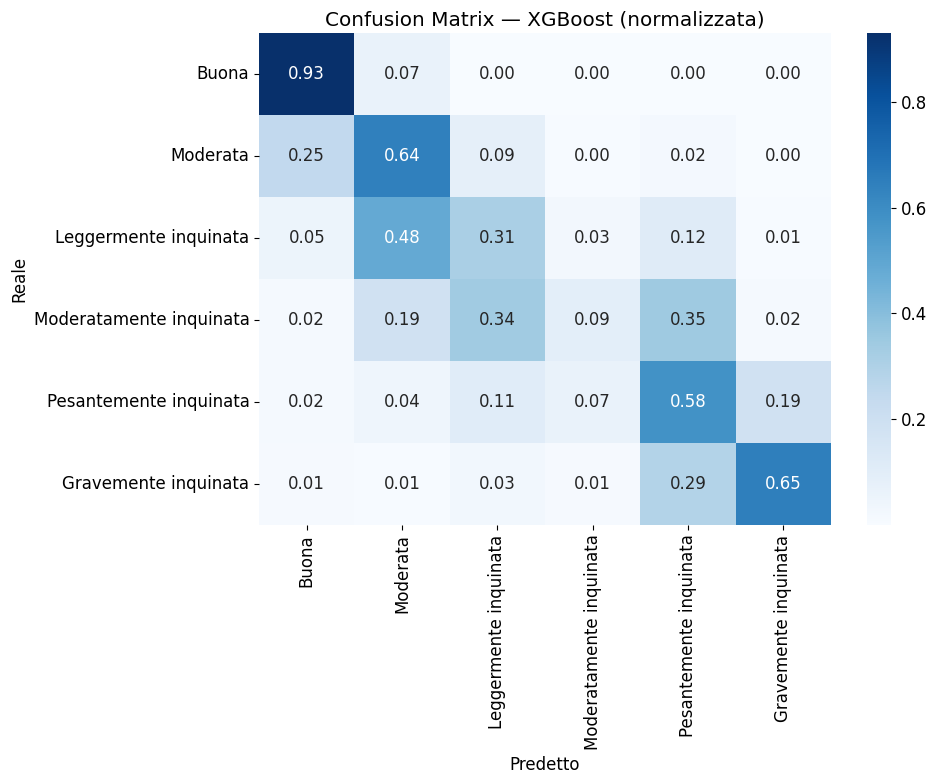


Classification Report — XGBoost:



'                         precision    recall  f1-score   support\n\n                  Buona       0.87      0.93      0.90     19066\n               Moderata       0.50      0.64      0.56      8405\n  Leggermente inquinata       0.39      0.31      0.35      6206\nModeratamente inquinata       0.34      0.09      0.15      4103\n Pesantemente inquinata       0.55      0.58      0.57      7064\n   Gravemente inquinata       0.59      0.65      0.62      3292\n\n               accuracy                           0.66     48136\n              macro avg       0.54      0.53      0.52     48136\n           weighted avg       0.63      0.66      0.64     48136\n'

In [66]:
best_clf = rs_xgb_clf
best_name = "XGBoost"
y_pred_best = best_clf.predict(X_test)

cm = confusion_matrix(y_test_class, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=aqi_names, yticklabels=aqi_names, ax=ax)
ax.set_xlabel('Predetto')
ax.set_ylabel('Reale')
ax.set_title(f'Confusion Matrix — {best_name} (normalizzata)')

plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}:\n")
classification_report(y_test_class, y_pred_best, target_names=aqi_names)

La confusion matrix di XGBoost evidenzia un comportamento atteso per un problema multi-classe con dati sbilanciati. Il modello classifica molto bene le classi estreme: "Buona" con recall del 93% e "Gravemente inquinata" con recall del 65%, le due fasce più nette in termini di concentrazione di PM2.5.

Le classi intermedie risultano invece più difficili da distinguere, come mostra la diagonale più debole. "Moderatamente inquinata" è la più problematica (recall dell'11%): viene spesso confusa con le classi adiacenti "Leggermente inquinata" e "Pesantemente inquinata". Questo è dovuto alla natura ordinale del problema, dove i confini tra fasce contigue sono basati su soglie arbitrarie di PM2.5 e le osservazioni vicine ai limiti sono intrinsecamente ambigue. Si nota infatti che gli errori si concentrano quasi sempre nelle celle immediatamente adiacenti alla diagonale, segno che il modello raramente sbaglia di più di una fascia.

Con un'accuracy del 66% e un F1 macro di 0.53, il modello risulta utile come sistema di allerta: identifica con buona affidabilità le situazioni di aria pulita e di inquinamento grave, che sono le più rilevanti dal punto di vista pratico, pur faticando nelle distinzioni più fini tra livelli intermedi.

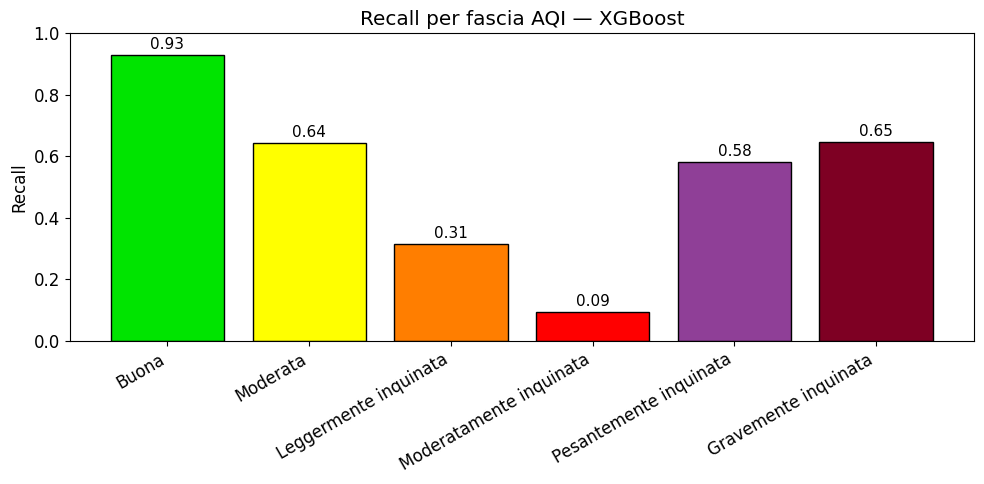

In [68]:
recall_per_class = cm.diagonal() / cm.sum(axis=1)
 
plt.figure(figsize=(10, 5))
bars = plt.bar(aqi_names, recall_per_class, color=aqi_colors, edgecolor='black')
plt.ylabel('Recall')
plt.title(f'Recall per fascia AQI — {best_name}')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
 
for bar, val in zip(bars, recall_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11)
 
plt.tight_layout()
plt.show()

Il grafico mostra il recall per ciascuna fascia AQI. La classe "Buona" ottiene il recall più alto (0.93), grazie alla sua abbondanza nel dataset. Le classi estreme di inquinamento ("Pesantemente inquinata" 0.59, "Gravemente inquinata" 0.65) hanno recall discreto nonostante i pochi campioni, merito del `class_weight='balanced'`.

La classe più critica è "Moderatamente inquinata" (0.11): si trova in una posizione intermedia e viene sistematicamente confusa con le fasce adiacenti. In un sistema di allerta reale questo rappresenta il limite principale del modello, poiché una fascia di rischio medio-alta viene spesso non riconosciuta.

## 8. Esportazione del modello di regressione

Per concludere, viene esportato il miglior modello di regressione, XGBoost in formato `.pkl` tramite `joblib`, per poterlo caricare e utilizzare nell'applicazione web.

In [62]:
import joblib

joblib.dump(rs_xgb.best_estimator_, 'model_xgb.pkl')

['model_xgb.pkl']

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fe8ba0a0-c743-4de6-b168-793b01eb47d6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>